# Experiment 1: Virtual Student Agent Fidelity (RQ2)

**Objective:** Validate that LLM-based virtual student agents faithfully encode and express FSLSM learning style profiles.

**RQ2:** *How accurately can LLM-based virtual student agents reproduce assigned FSLSM learning style profiles?*

---

**Design:**
- 16 FSLSM profiles × 5 instances = 80 agents per model, plus 5 non-personalized baseline agents
- 3 ILS trials per agent (44 questions each)
- Models: `gpt-4.1-mini`, `claude-sonnet-4-20250514`, `llama3.1:8b`, `qwen2.5:7b`, `gemma2:9b`, `gemma3:12b`

**Metrics:**
- **PRA (Profile Recovery Accuracy):** Fraction of dimensions where sign(detected) matches assigned pole
- **DAS (Dimension Alignment Score):** `(raw_score × assigned + 11) / 22` — continuous [0, 1] alignment strength

In [3]:
%matplotlib inline
import sys, json
from pathlib import Path

# Project root
PROJECT_ROOT = Path.cwd().parents[1] if Path.cwd().name == "exp1_agent_fidelity" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config.constants import FSLSM_DIMENSIONS, FSLSM_DIM_LABELS

# Human-readable axis labels  e.g. "Active/Reflective"
DIM_AXIS_LABELS = [f"{neg}/{pos}" for neg, pos in FSLSM_DIM_LABELS.values()]

MODELS = [
    "gpt-4.1-mini",
    "claude-sonnet-4-20250514",
    "llama3.1:8b",
    "qwen2.5:7b",
    "gemma2:9b",
    "gemma3:12b",
    "qwen2.5:3b",
    "gemma3:4b",
    "llama3.2:3b",
    "phi4-mini",
]
METRICS_DIR = PROJECT_ROOT / "results" / "exp1" / "metrics"

print(f"Project root : {PROJECT_ROOT}")
print(f"Metrics dir  : {METRICS_DIR.exists()}")
print(f"Dimensions   : {FSLSM_DIMENSIONS}")
print(f"Axis labels  : {DIM_AXIS_LABELS}")

Project root : /Users/nyeinchanaung/Documents/GitHub/mcp-rag
Metrics dir  : True
Dimensions   : ['act_ref', 'sen_int', 'vis_ver', 'seq_glo']
Axis labels  : ['Active/Reflective', 'Sensing/Intuitive', 'Visual/Verbal', 'Sequential/Global']


In [4]:
# Load all CSV data
df_pra = pd.read_csv(METRICS_DIR / "pra_das_summary.csv")
df_das = pd.read_csv(METRICS_DIR / "das_summary.csv")
df_baseline_style = pd.read_csv(METRICS_DIR / "baseline_natural_style.csv")
df_cost = pd.read_csv(METRICS_DIR / "cost_summary.csv")
df_pq = pd.read_csv(METRICS_DIR / "per_question_alignment.csv")

print(f"PRA rows: {len(df_pra)}, DAS rows: {len(df_das)}")
print(f"Baseline style rows: {len(df_baseline_style)}, Cost rows: {len(df_cost)}")
print(f"Per-question alignment rows: {len(df_pq)}")

PRA rows: 90, DAS rows: 250
Baseline style rows: 10, Cost rows: 20
Per-question alignment rows: 440


## 1. PRA Summary (Overall)

In [5]:
# PRA overall summary (FSLSM agents)
pra_overall = df_pra[
    (df_pra["dimension"] == "overall_4d") & (df_pra["knowledge_level"] == "ALL")
][["model", "pra", "ties"]]
pra_overall.style.format({"pra": "{:.3f}"}).set_caption("PRA Overall (4D)")

,model,pra,ties
4,gpt-4.1-mini,0.996,0
13,claude-sonnet-4-20250514,1.000,0
22,llama3.1:8b,0.724,0
31,qwen2.5:7b,0.956,0
40,gemma2:9b,0.948,0
49,gemma3:12b,1.000,0
58,qwen2.5:3b,0.890,0
67,gemma3:4b,0.718,0
76,llama3.2:3b,0.902,23
85,phi4-mini,0.915,0


### PRA Per-Dimension (FSLSM Agents)

In [6]:
# PRA per dimension
pra_dim = df_pra[
    (df_pra["knowledge_level"] == "ALL")
    & (df_pra["dimension"] != "overall_4d")
].pivot(index="dimension", columns="model", values="pra")
pra_dim.style.format("{:.3f}").set_caption("PRA by Dimension")

model,claude-sonnet-4-20250514,gemma2:9b,gemma3:12b,gemma3:4b,gpt-4.1-mini,llama3.1:8b,llama3.2:3b,phi4-mini,qwen2.5:3b,qwen2.5:7b
dimension,,,,,,,,,,
act_ref,1.000,1.000,1.000,0.938,1.000,1.000,0.925,0.829,0.750,0.850
sen_int,1.000,0.975,1.000,0.588,1.000,0.500,0.892,0.958,1.000,0.996
seq_glo,1.000,0.817,1.000,0.613,0.983,0.517,0.821,0.900,0.812,0.979
vis_ver,1.000,1.000,1.000,0.733,1.000,0.879,0.971,0.971,0.996,1.000


### PRA by Knowledge Level

In [7]:
# PRA by knowledge level (overall_4d)
pra_kl = df_pra[
    df_pra["dimension"] == "overall_4d"
].pivot(index="knowledge_level", columns="model", values="pra")
pra_kl.style.format("{:.3f}").set_caption("PRA by Knowledge Level")

model,claude-sonnet-4-20250514,gemma2:9b,gemma3:12b,gemma3:4b,gpt-4.1-mini,llama3.1:8b,llama3.2:3b,phi4-mini,qwen2.5:3b,qwen2.5:7b
knowledge_level,,,,,,,,,,
ALL,1.000,0.948,1.000,0.718,0.996,0.724,0.902,0.915,0.890,0.956
advanced,1.000,0.953,1.000,0.714,0.984,0.719,0.917,0.927,0.906,0.953
beginner,1.000,0.922,1.000,0.625,0.995,0.724,0.891,0.901,0.901,0.932
general,1.000,0.953,1.000,0.753,1.000,0.721,0.896,0.919,0.898,0.964
intermediate,1.000,0.958,1.000,0.745,1.000,0.734,0.911,0.906,0.844,0.969


## 2. DAS Summary (Overall)

In [8]:
# DAS overall summary
das_overall = df_das[
    (df_das["dimension"] == "overall_4d") & (df_das["knowledge_level"] == "ALL")
][["model", "das"]]
das_overall.style.format({"das": "{:.3f}"}).set_caption("DAS Overall (4D)")

,model,das
4,gpt-4.1-mini,0.924
9,claude-sonnet-4-20250514,0.927
14,llama3.1:8b,0.741
19,qwen2.5:7b,0.785
24,gemma2:9b,0.837
29,gemma3:12b,0.882
34,qwen2.5:3b,0.752
39,gemma3:4b,0.718
44,llama3.2:3b,0.708
49,phi4-mini,0.722


### DAS Per-Dimension (FSLSM Agents)

In [9]:
# DAS per dimension
das_dim = df_das[
    (df_das["knowledge_level"] == "ALL")
    & (df_das["dimension"] != "overall_4d")
].pivot(index="dimension", columns="model", values="das")
das_dim.style.format("{:.3f}").set_caption("DAS by Dimension")

model,claude-sonnet-4-20250514,gemma2:9b,gemma3:12b,gemma3:4b,gpt-4.1-mini,llama3.1:8b,llama3.2:3b,phi4-mini,qwen2.5:3b,qwen2.5:7b
dimension,,,,,,,,,,
act_ref,0.953,0.921,0.949,0.822,0.984,0.864,0.738,0.803,0.723,0.794
sen_int,0.910,0.850,0.825,0.712,0.870,0.687,0.678,0.724,0.803,0.747
seq_glo,0.862,0.650,0.769,0.592,0.868,0.622,0.630,0.625,0.628,0.700
vis_ver,0.982,0.925,0.986,0.745,0.974,0.792,0.788,0.736,0.852,0.900


## 3. Visualizations

### 3.1 Model Comparison — PRA per Dimension

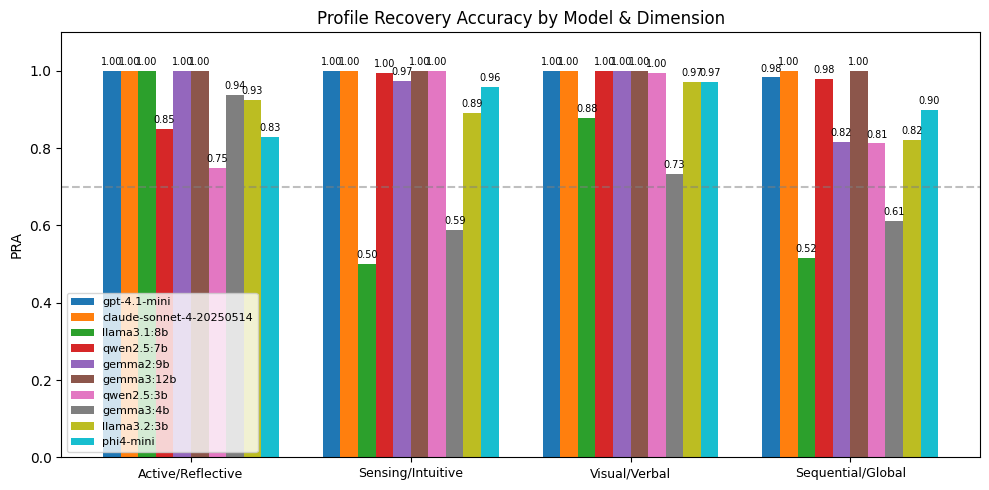

In [10]:
# ── 3.1  Model Comparison — PRA per Dimension ────────────────────────
df = df_pra[
    (df_pra["knowledge_level"] == "ALL")
    & (df_pra["dimension"] != "overall_4d")
].copy()

models = df["model"].unique()
x = np.arange(len(FSLSM_DIMENSIONS))
width = 0.8 / len(models)

fig, ax = plt.subplots(figsize=(10, 5))
for i, model in enumerate(models):
    md = df[df["model"] == model]
    vals = [md[md["dimension"] == d]["pra"].values[0]
            if len(md[md["dimension"] == d]) else 0 for d in FSLSM_DIMENSIONS]
    bars = ax.bar(x + i * width, vals, width, label=model)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{v:.2f}", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x + width * (len(models) - 1) / 2)
ax.set_xticklabels(DIM_AXIS_LABELS, fontsize=9)
ax.set_ylabel("PRA")
ax.set_ylim(0, 1.1)
ax.set_title("Profile Recovery Accuracy by Model & Dimension")
ax.axhline(y=0.7, color="gray", linestyle="--", alpha=0.5)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 3.2 Knowledge Level — PRA Comparison

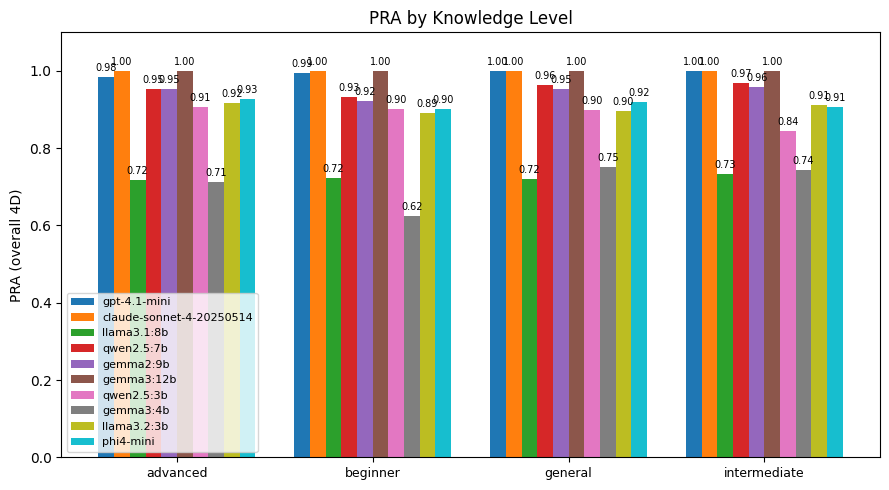

In [11]:
# ── 3.2  Knowledge Level — PRA Comparison ────────────────────────────
df = df_pra[
    (df_pra["dimension"] == "overall_4d")
    & (df_pra["knowledge_level"] != "ALL")
].copy()

models = df["model"].unique()
levels = sorted(df["knowledge_level"].unique())
x = np.arange(len(levels))
width = 0.8 / len(models)

fig, ax = plt.subplots(figsize=(9, 5))
for i, model in enumerate(models):
    md = df[df["model"] == model]
    vals = [md[md["knowledge_level"] == lv]["pra"].values[0]
            if len(md[md["knowledge_level"] == lv]) else 0 for lv in levels]
    bars = ax.bar(x + i * width, vals, width, label=model)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{v:.2f}", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x + width * (len(models) - 1) / 2)
ax.set_xticklabels(levels, fontsize=9)
ax.set_ylabel("PRA (overall 4D)")
ax.set_ylim(0, 1.1)
ax.set_title("PRA by Knowledge Level")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 3.3 DAS Comparison — Per Dimension

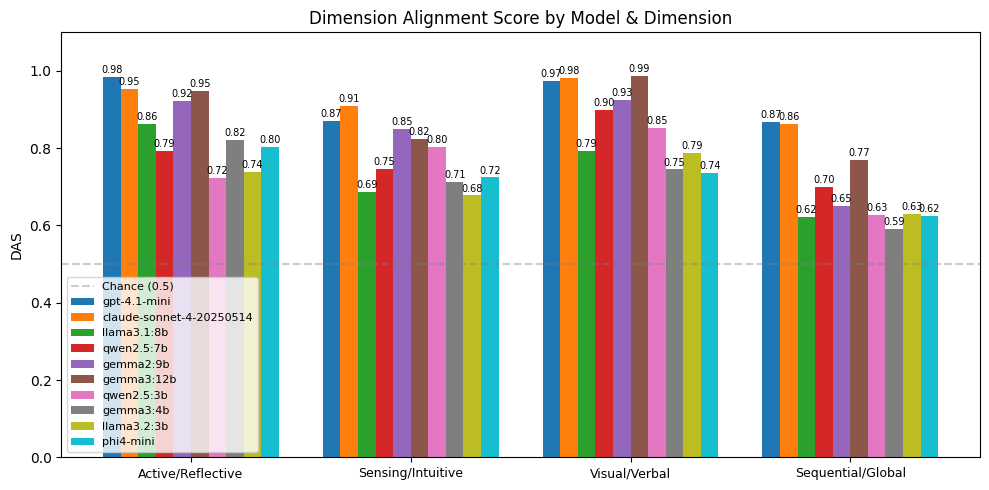

In [12]:
# ── 3.3  DAS Comparison — Per Dimension ──────────────────────────────
df = df_das[
    (df_das["knowledge_level"] == "ALL")
    & (df_das["dimension"] != "overall_4d")
].copy()

models = df["model"].unique()
x = np.arange(len(FSLSM_DIMENSIONS))
width = 0.8 / len(models)

fig, ax = plt.subplots(figsize=(10, 5))
for i, model in enumerate(models):
    md = df[df["model"] == model]
    vals = [md[md["dimension"] == d]["das"].values[0]
            if len(md[md["dimension"] == d]) else 0.0 for d in FSLSM_DIMENSIONS]
    bars = ax.bar(x + i * width, vals, width, label=model)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{v:.2f}", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x + width * (len(models) - 1) / 2)
ax.set_xticklabels(DIM_AXIS_LABELS, fontsize=9)
ax.set_ylabel("DAS")
ax.set_ylim(0, 1.1)
ax.set_title("Dimension Alignment Score by Model & Dimension")
ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.4, label="Chance (0.5)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 3.4 FSLSM Profile Heatmaps (Raw Scores per Model)

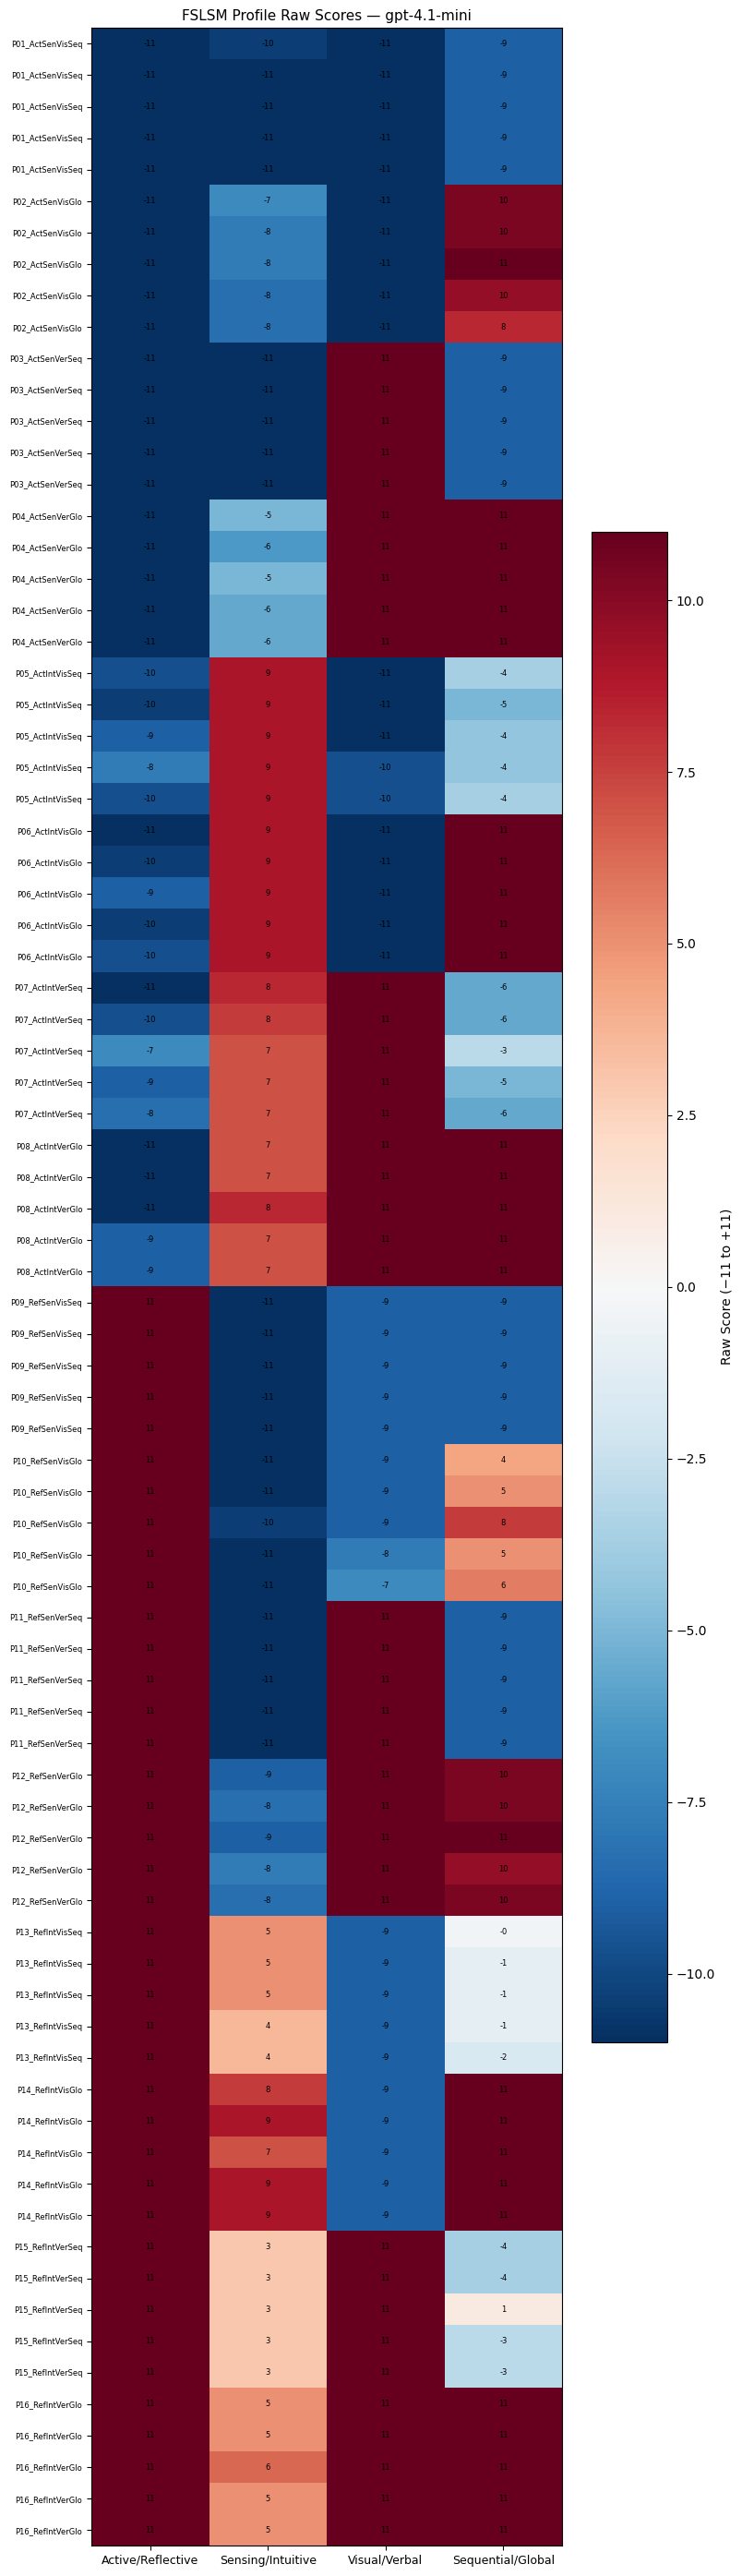

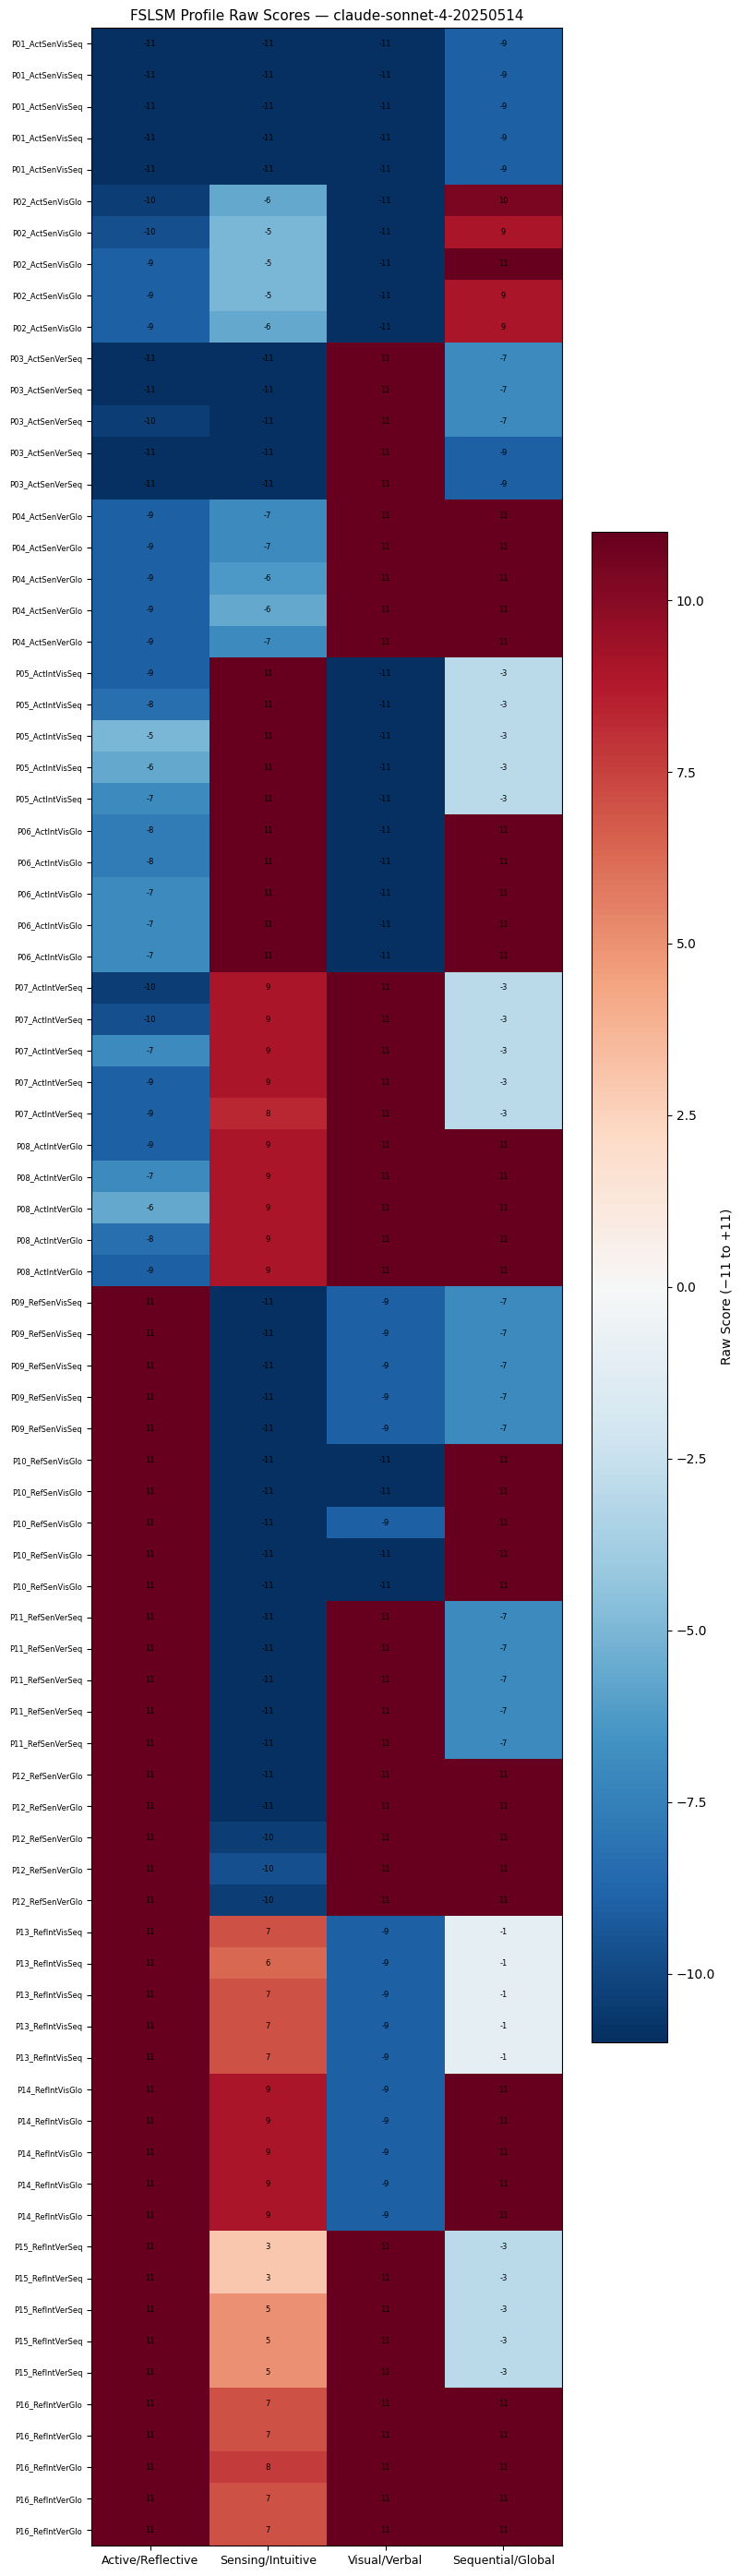

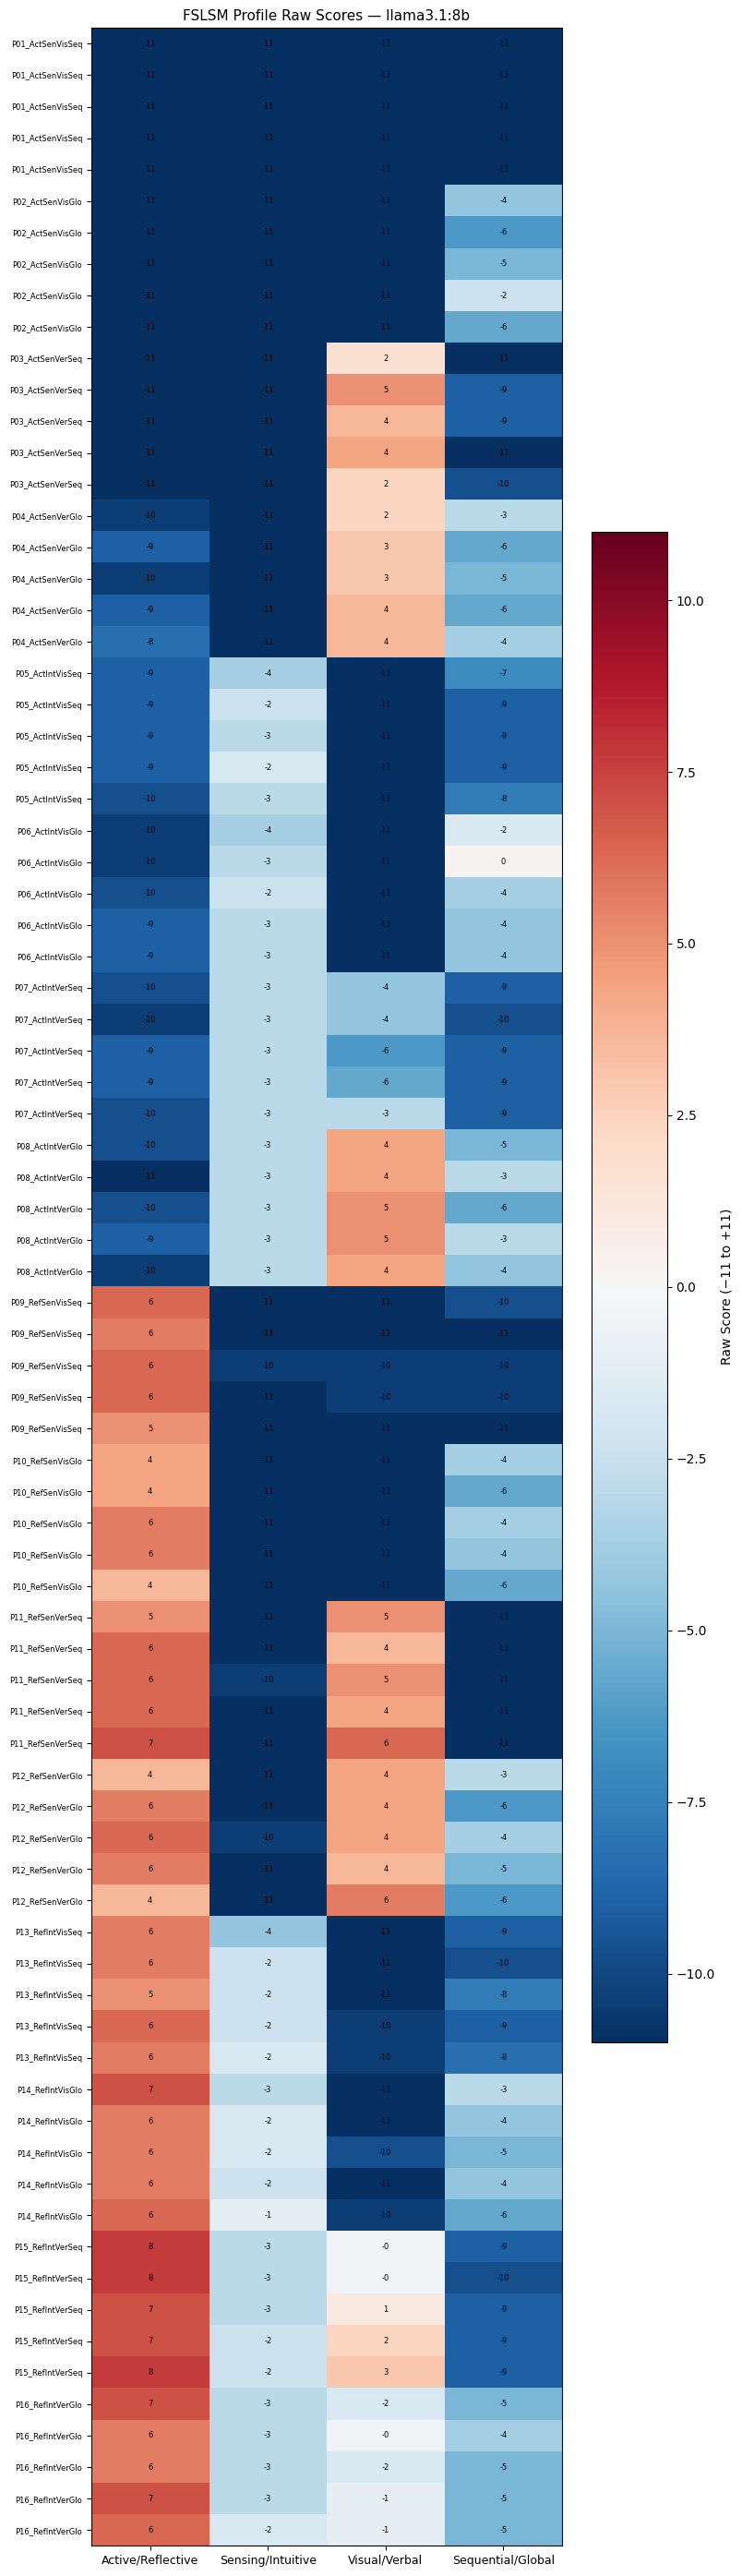

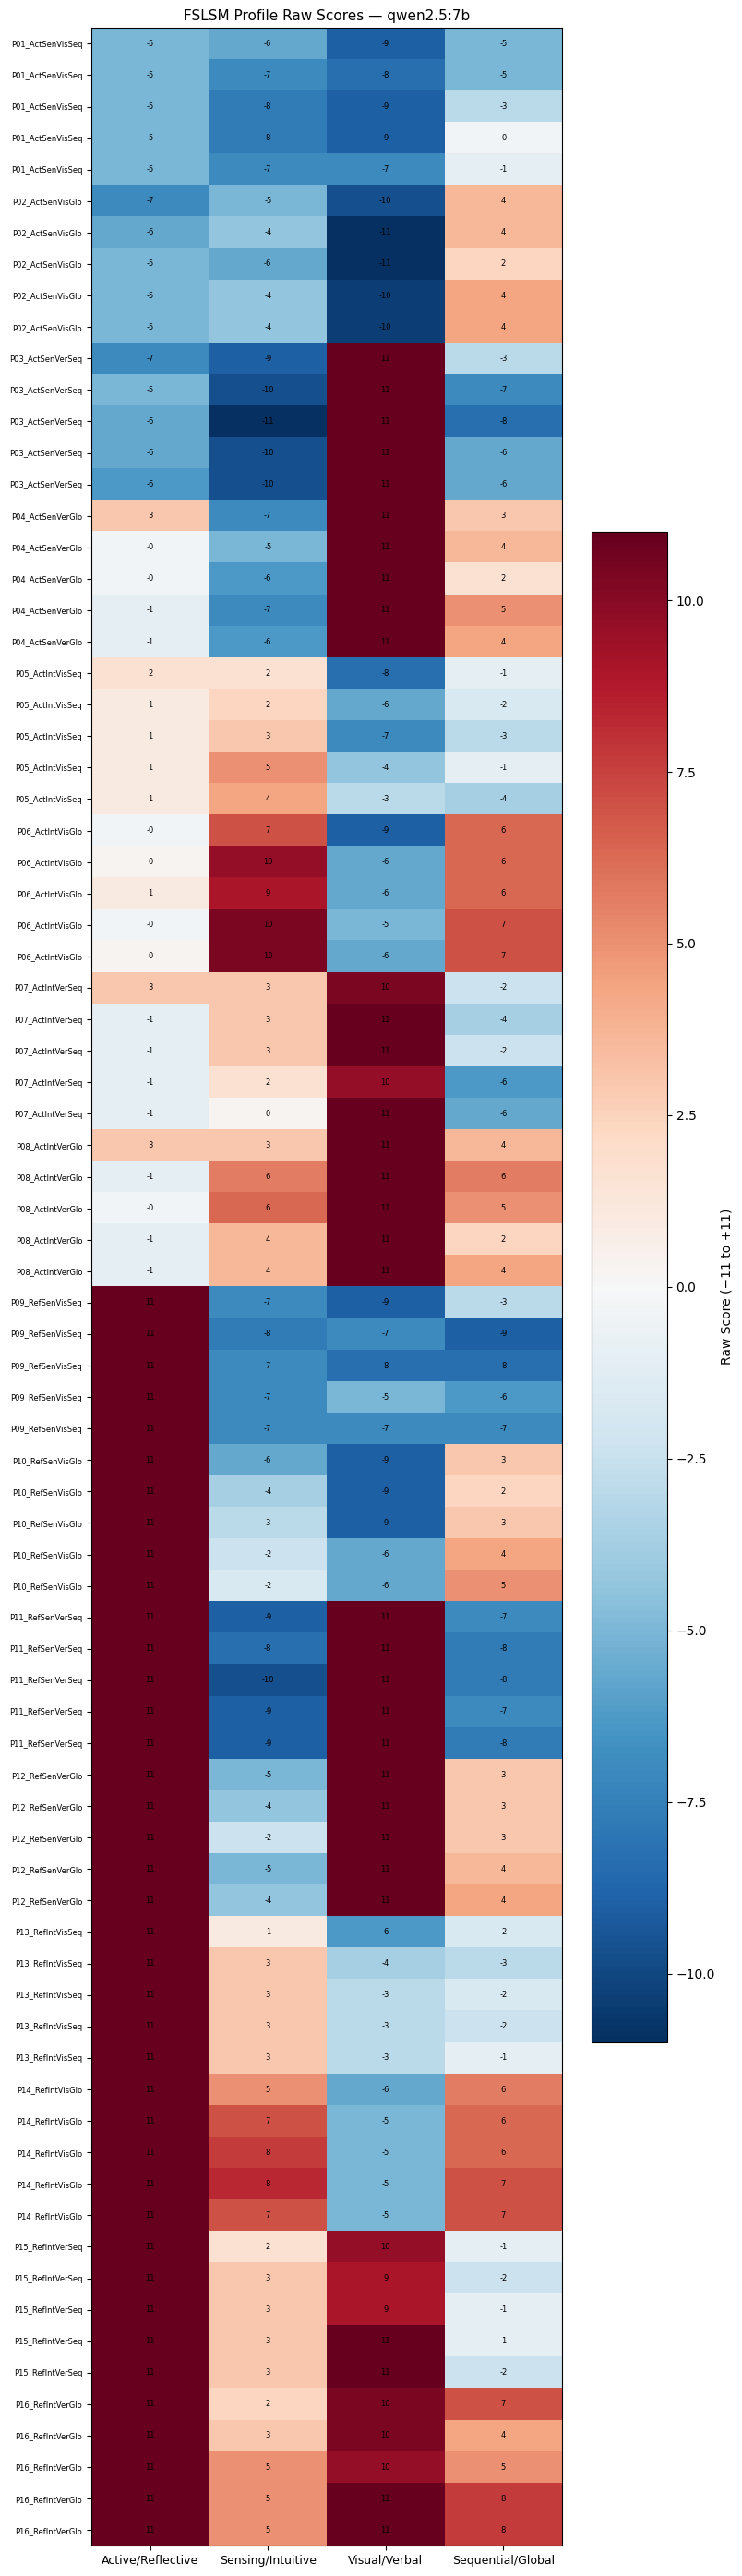

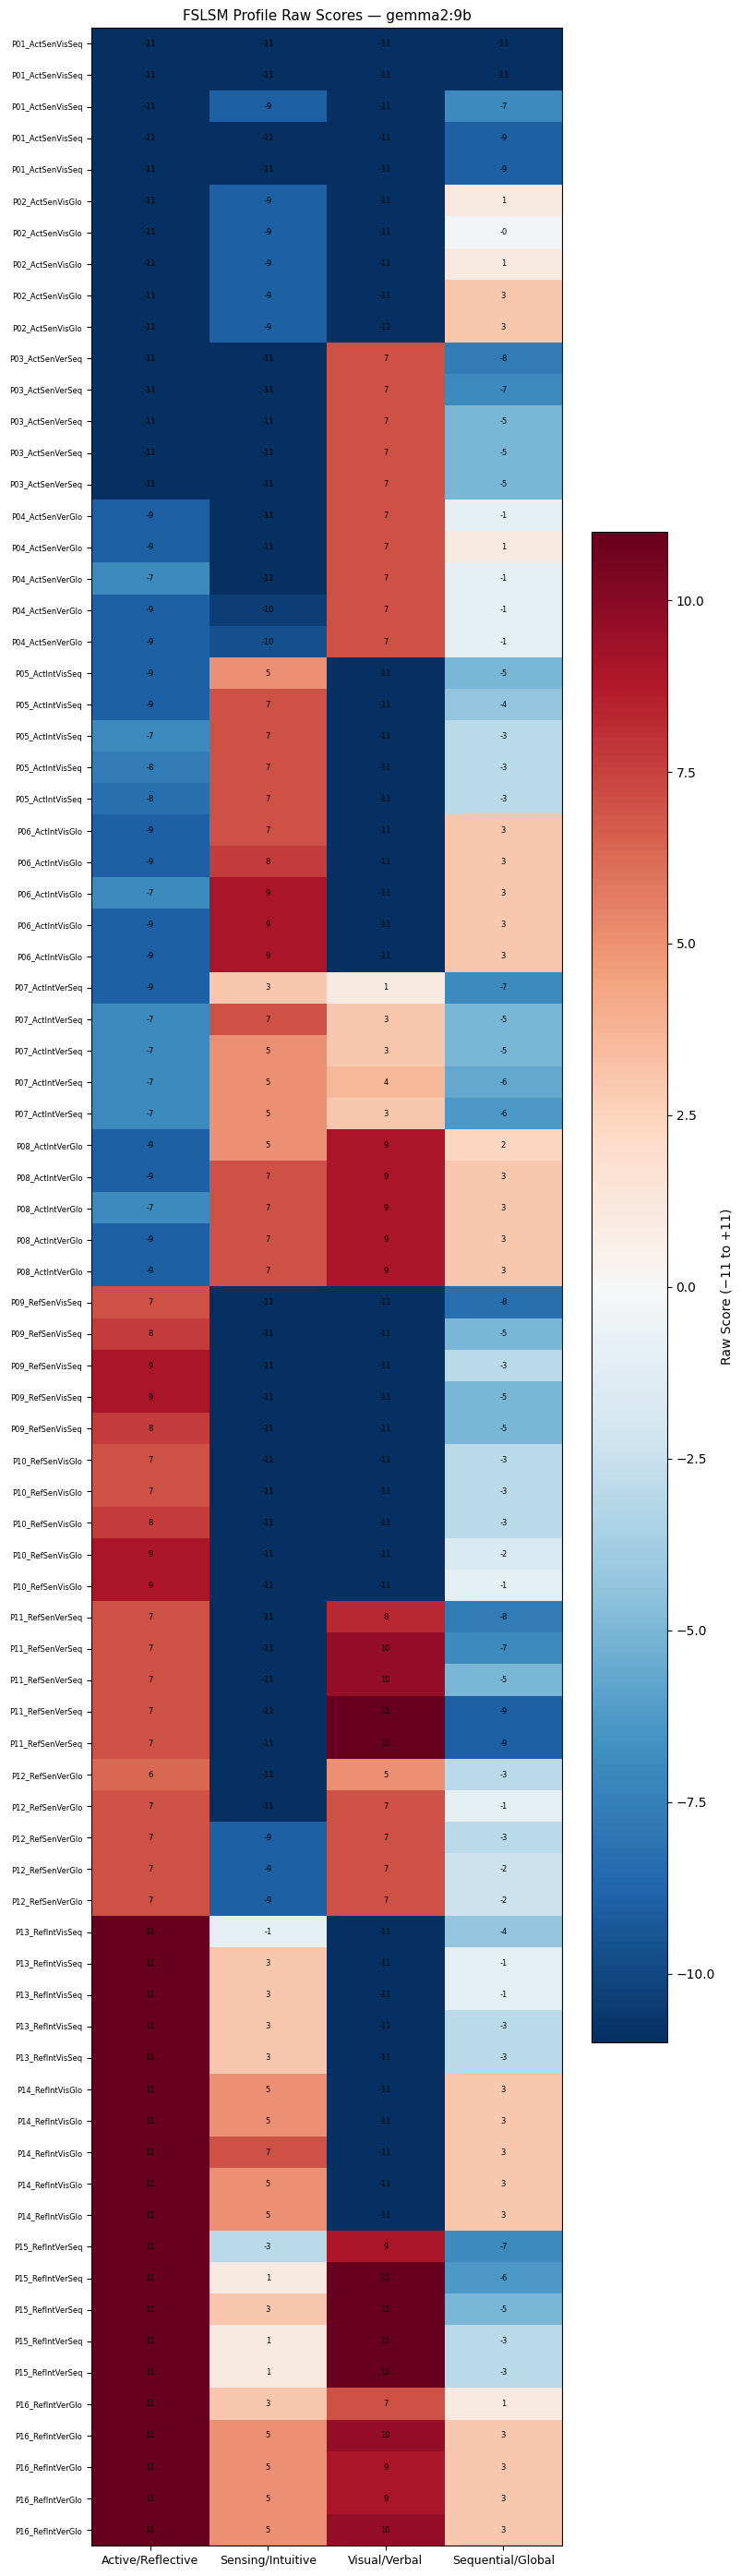

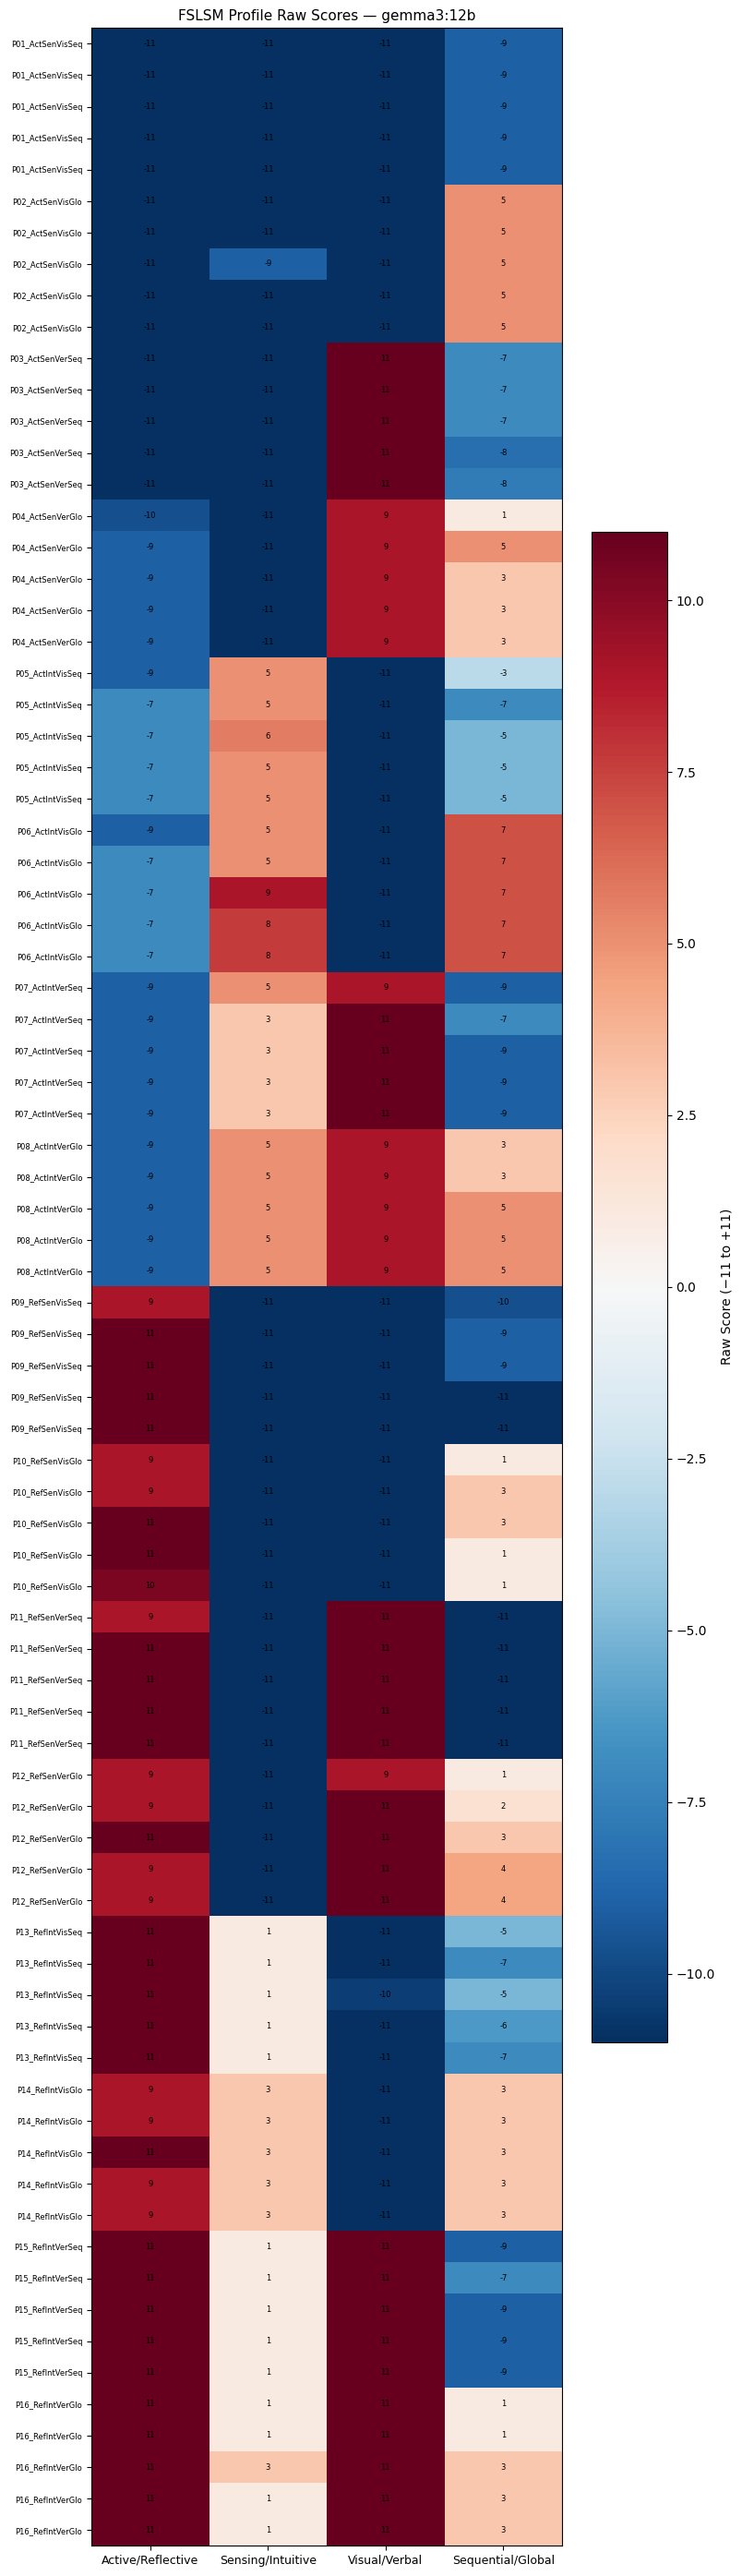

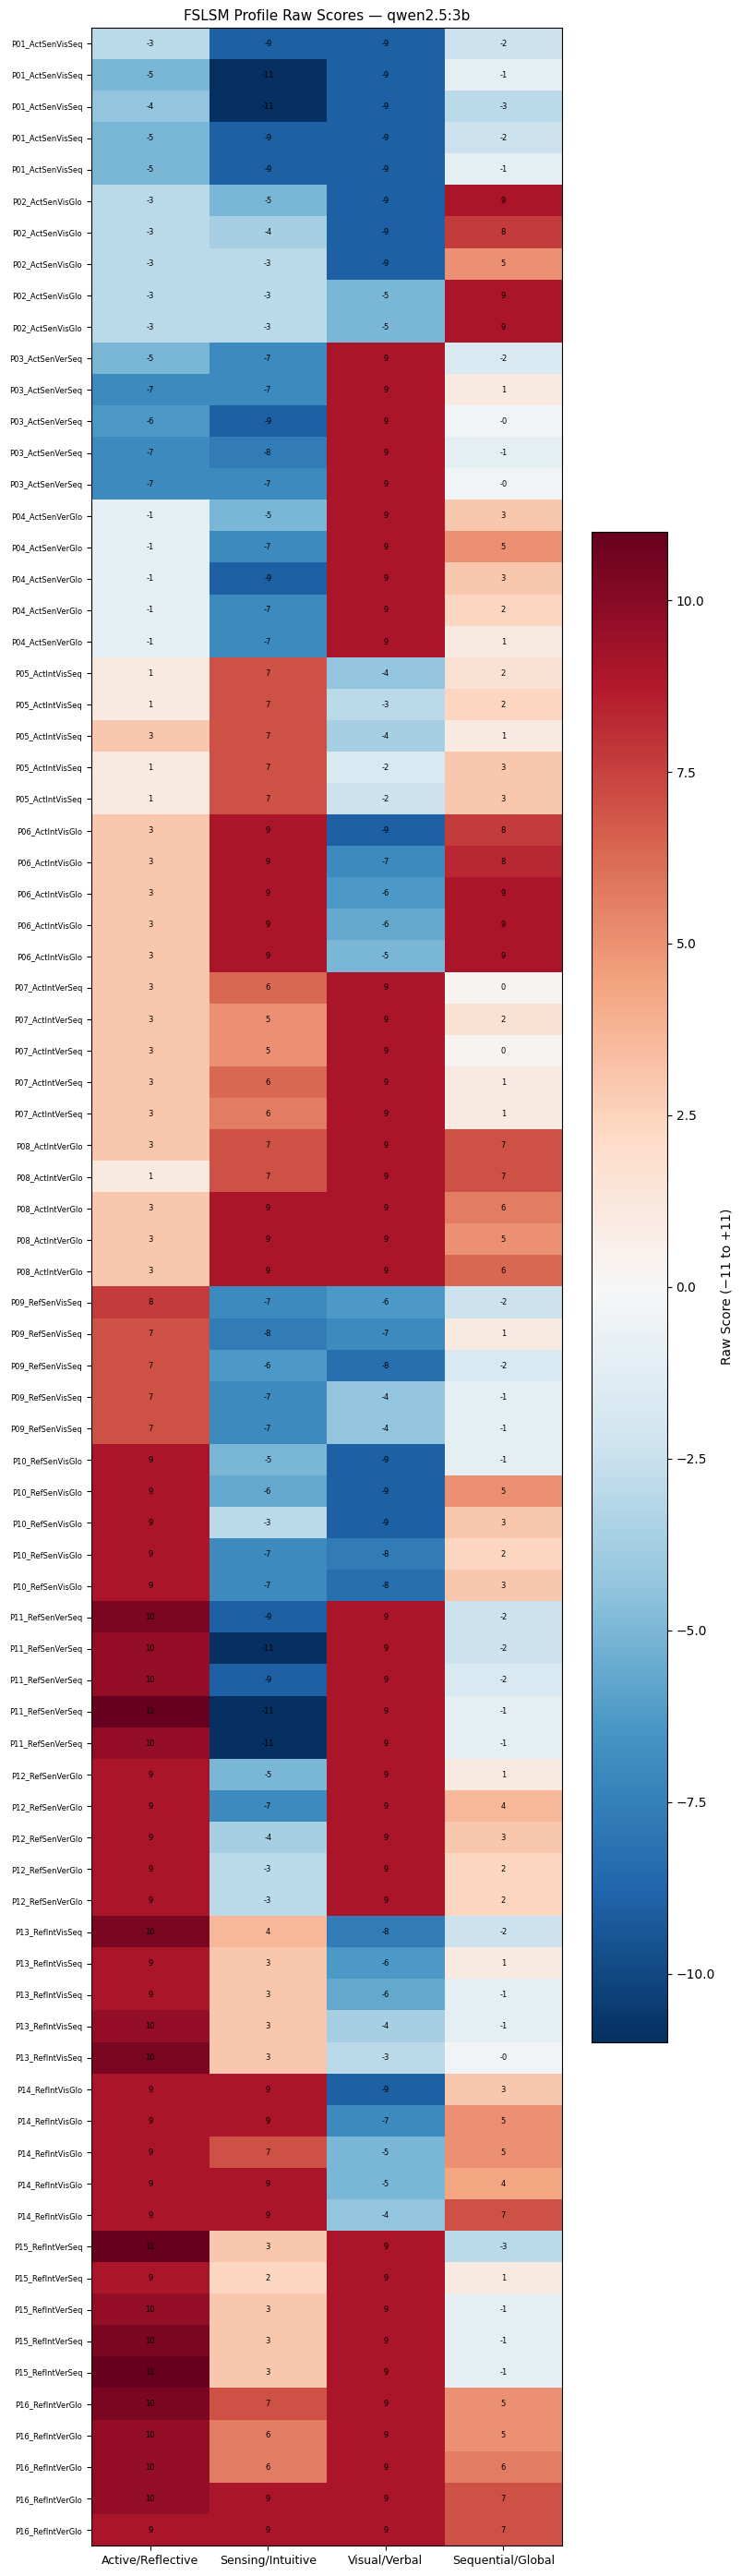

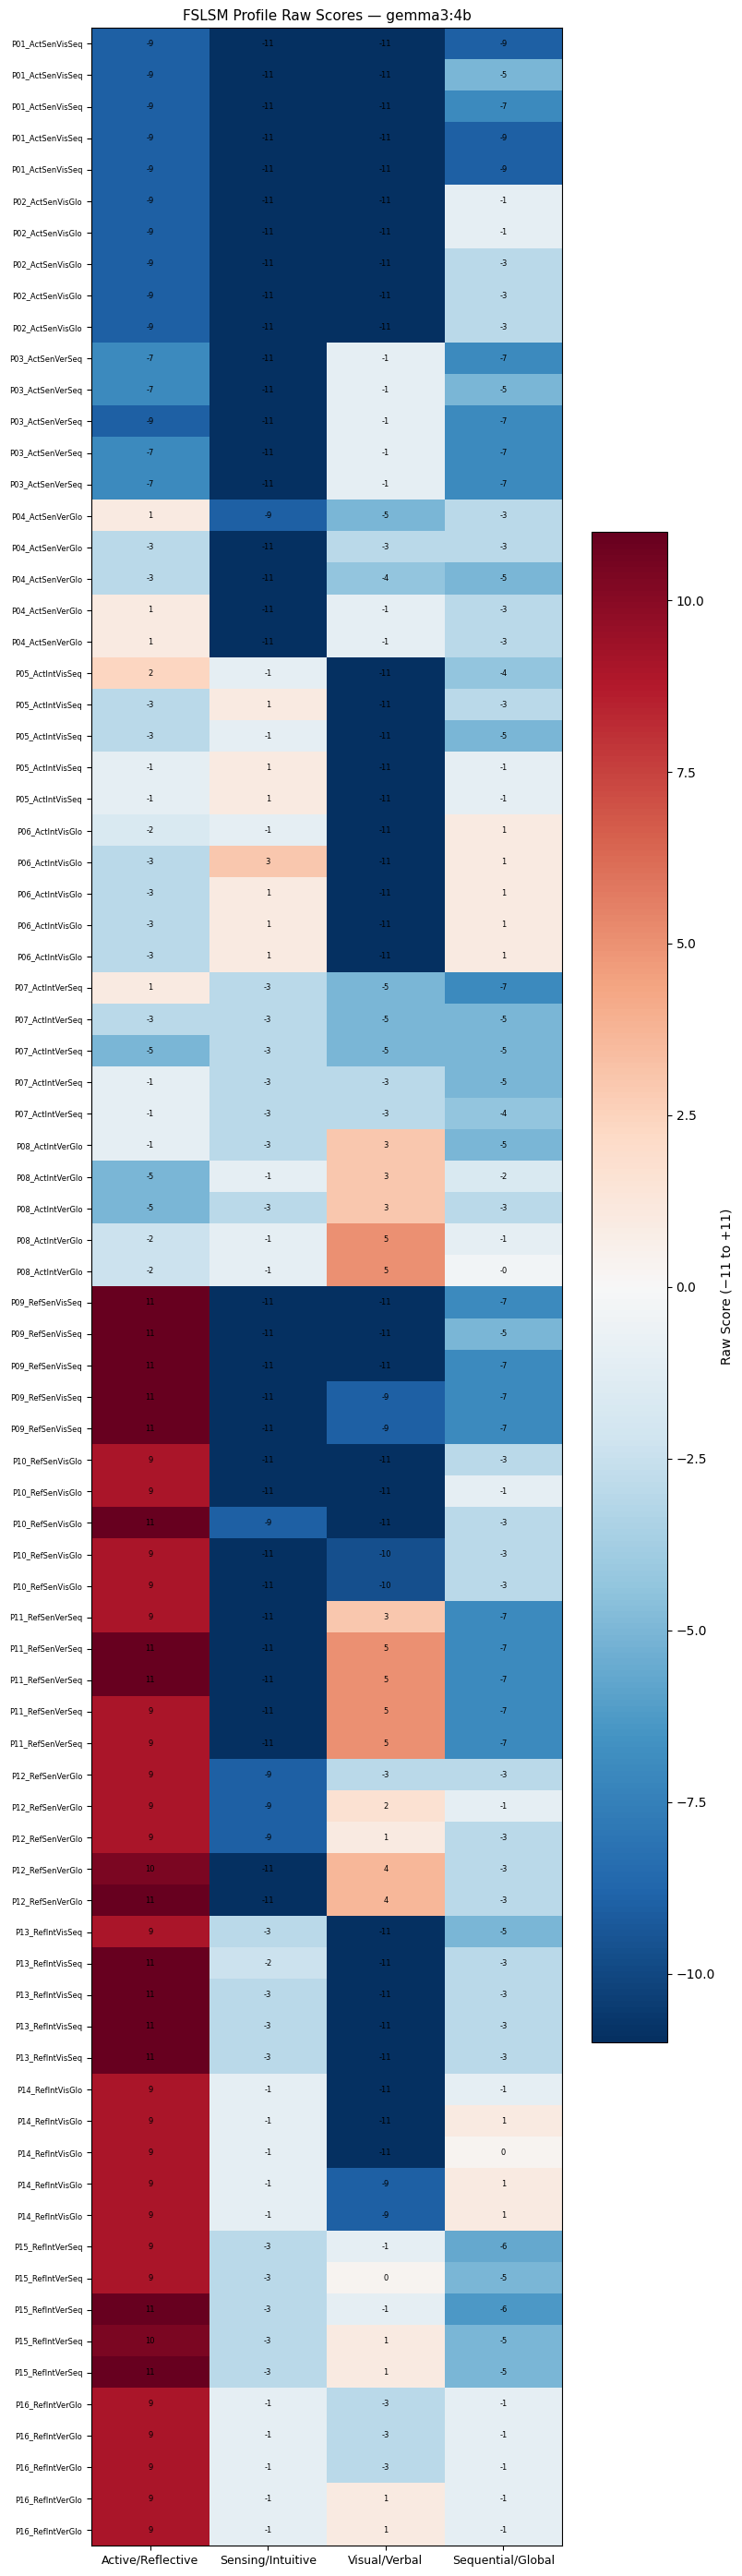

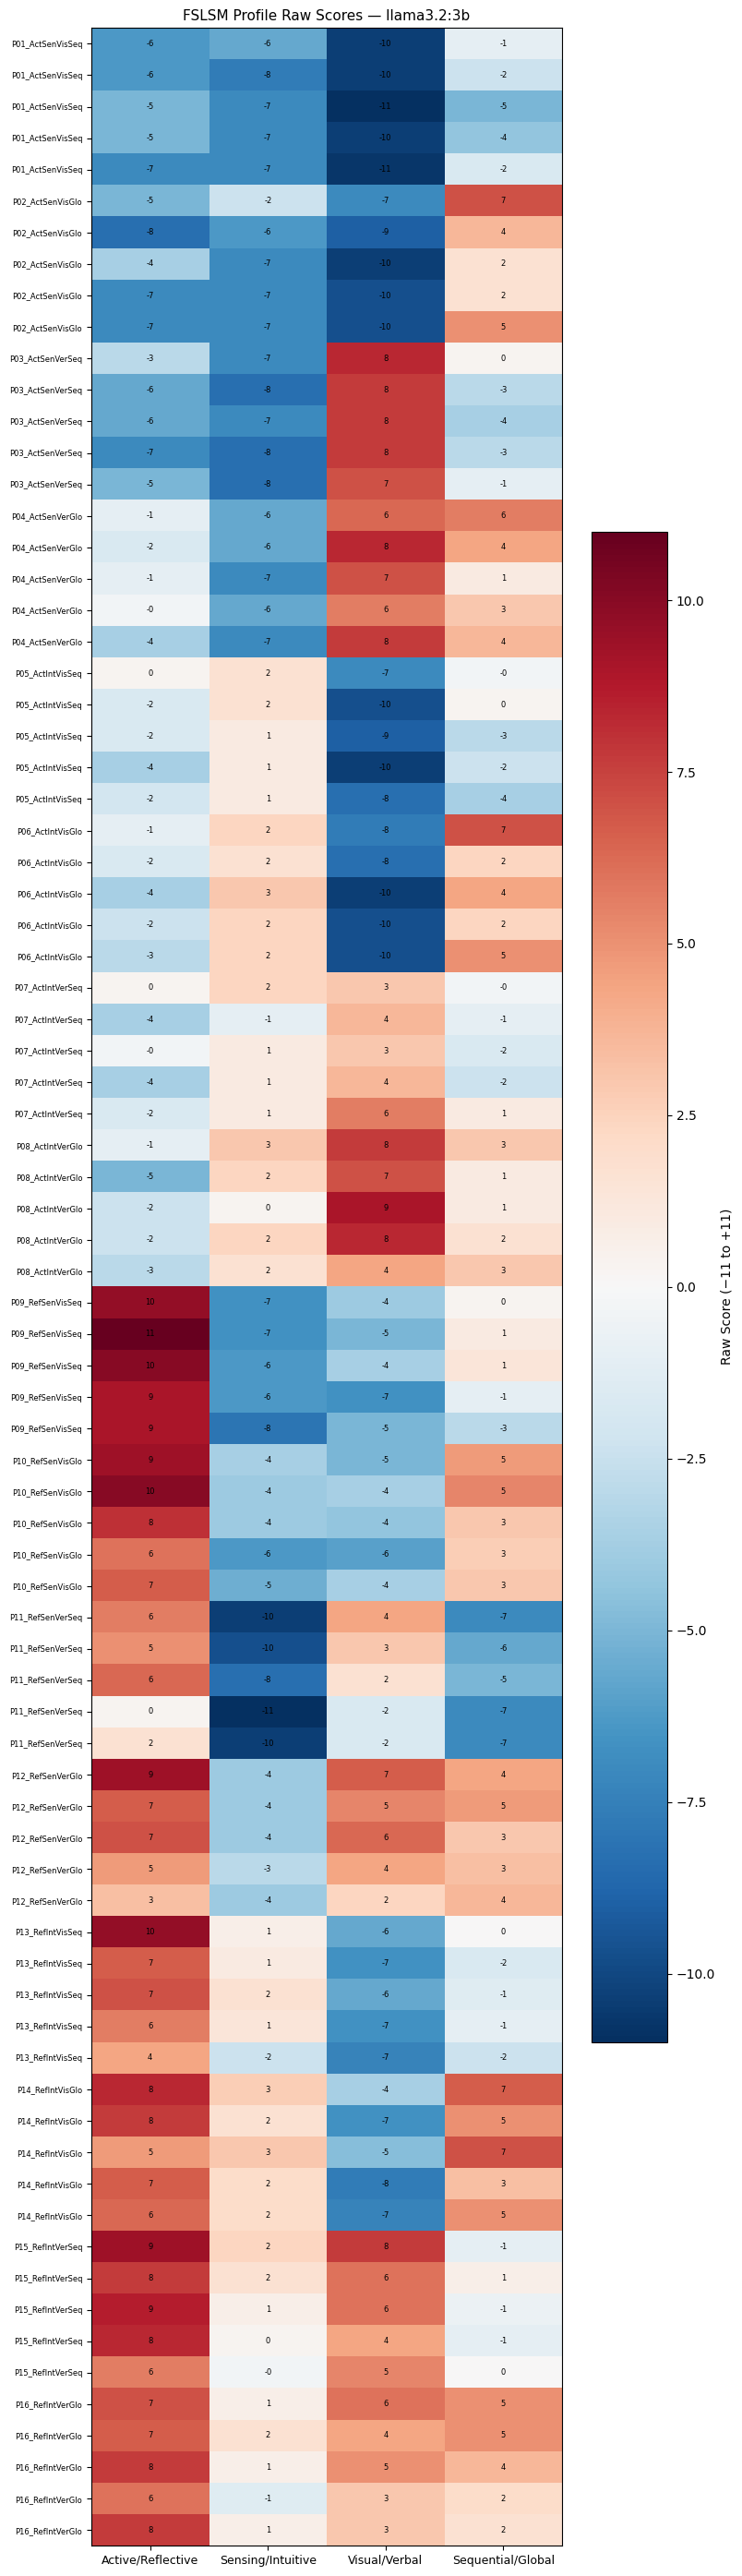

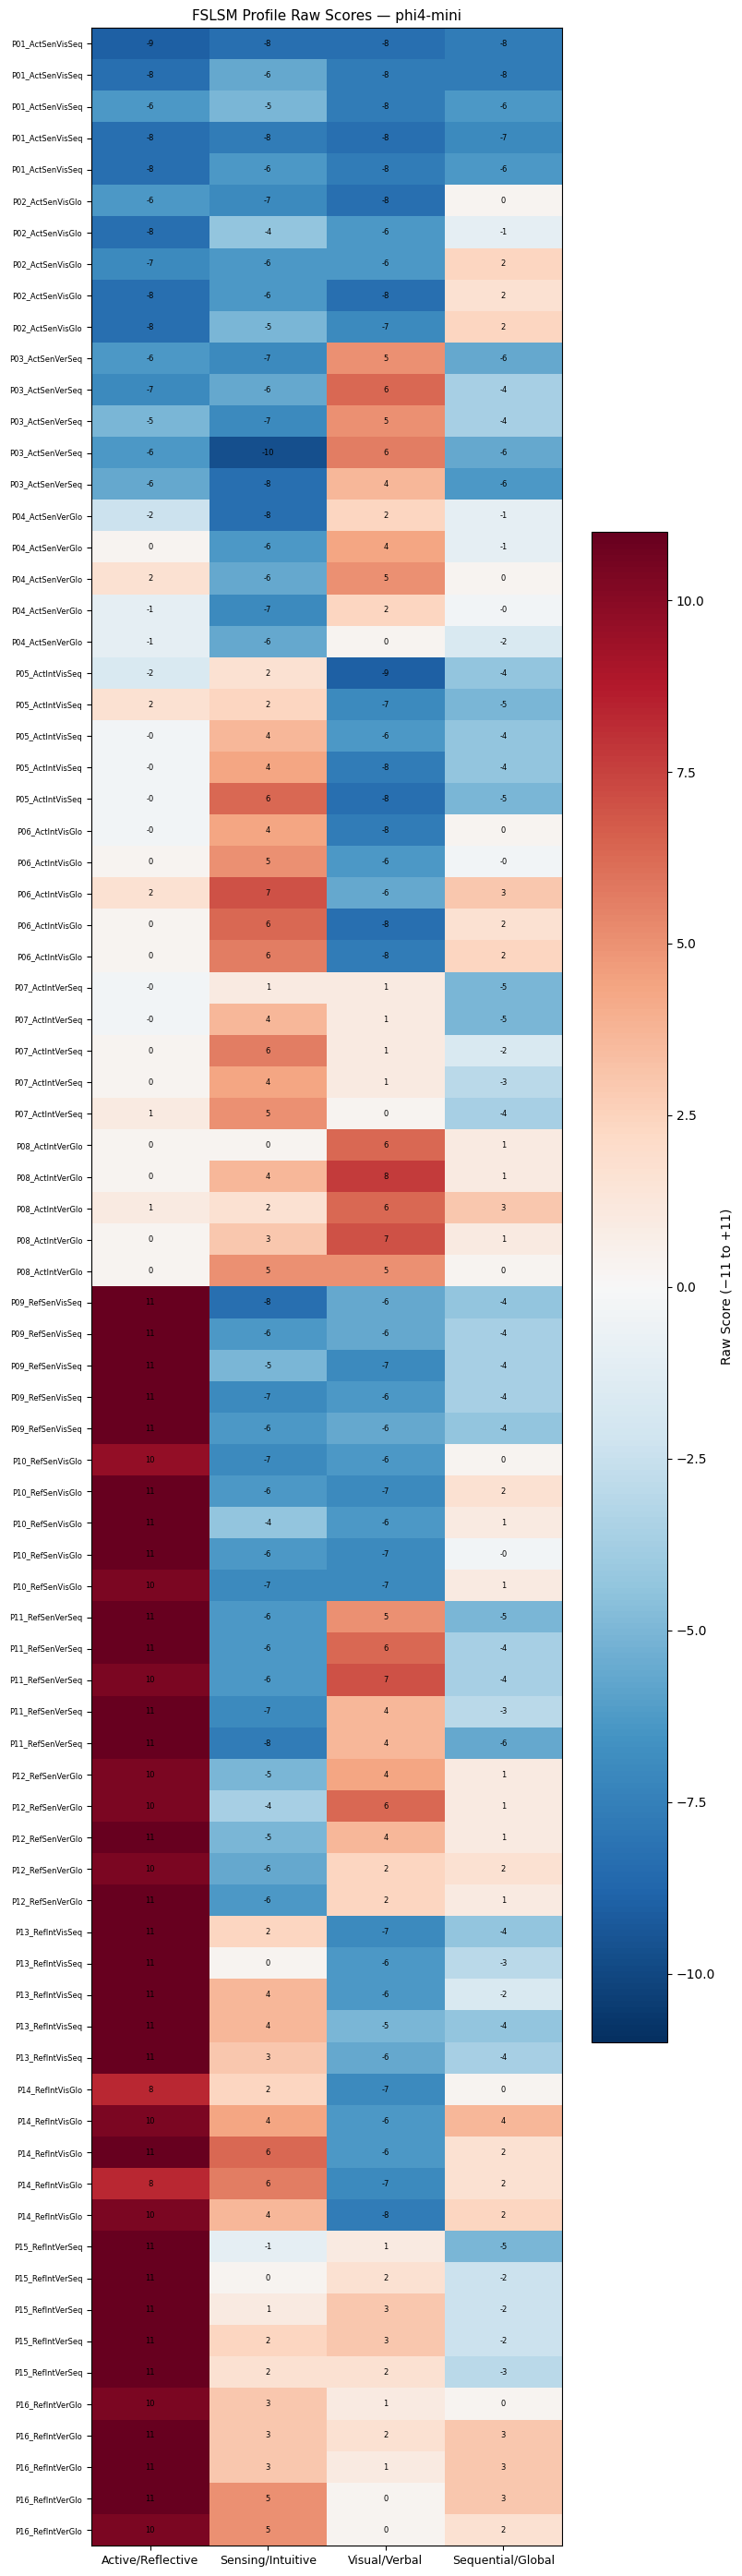

In [13]:
# ── 3.4  FSLSM Profile Heatmaps (Raw Scores per Model) ──────────────
for model in MODELS:
    safe = model.replace("/", "_").replace(":", "_")
    results_file = METRICS_DIR / f"{safe}_results.json"
    if not results_file.exists():
        print(f"Skipping {model} — file not found")
        continue

    results = json.loads(results_file.read_text())

    # Build matrix: agents × dimensions (mean across trials)
    agent_data: dict = {}
    for r in results:
        uid = r["agent_uid"]
        if uid not in agent_data:
            agent_data[uid] = {"scores": {d: [] for d in FSLSM_DIMENSIONS},
                               "profile_code": r["profile_code"]}
        for d in FSLSM_DIMENSIONS:
            agent_data[uid]["scores"][d].append(r["raw_scores"][d])

    agent_uids = sorted(agent_data.keys())
    matrix = np.array([
        [np.mean(agent_data[uid]["scores"][d]) for d in FSLSM_DIMENSIONS]
        for uid in agent_uids
    ])
    profile_labels = [agent_data[uid]["profile_code"] for uid in agent_uids]

    fig, ax = plt.subplots(figsize=(8, max(6, len(agent_uids) * 0.35)))
    im = ax.imshow(matrix, cmap="RdBu_r", aspect="auto", vmin=-11, vmax=11)
    ax.set_xticks(range(len(FSLSM_DIMENSIONS)))
    ax.set_xticklabels(DIM_AXIS_LABELS, fontsize=9)
    ax.set_yticks(range(len(agent_uids)))
    ax.set_yticklabels(profile_labels, fontsize=6)
    ax.set_title(f"FSLSM Profile Raw Scores — {model}", fontsize=11)
    for i in range(len(agent_uids)):
        for j in range(len(FSLSM_DIMENSIONS)):
            ax.text(j, i, f"{matrix[i, j]:.0f}", ha="center", va="center", fontsize=6)
    fig.colorbar(im, ax=ax, shrink=0.6, label="Raw Score (−11 to +11)")
    plt.tight_layout()
    plt.show()

## 4. Baseline Natural Learning Style

Without any persona, which learning style does each LLM naturally exhibit when answering the ILS?
Computed from 5 baseline agents × 3 trials each (15 records per model).

In [14]:
# Baseline natural learning style — one row per model
style_cols = ["model", "detected_style",
              "act_ref_mean_score", "sen_int_mean_score",
              "vis_ver_mean_score", "seq_glo_mean_score"]
df_baseline_style[style_cols].style.format({
    "act_ref_mean_score": "{:.2f}",
    "sen_int_mean_score": "{:.2f}",
    "vis_ver_mean_score": "{:.2f}",
    "seq_glo_mean_score": "{:.2f}",
}).set_caption("LLM Natural Learning Style (No Persona)")

,model,detected_style,act_ref_mean_score,sen_int_mean_score,vis_ver_mean_score,seq_glo_mean_score
0,gpt-4.1-mini,Reflective-Intuitive-Visual-Global,5.40,3.00,-6.60,3.80
1,claude-sonnet-4-20250514,Reflective-Intuitive-Verbal-Global,10.07,9.27,6.73,9.80
2,llama3.1:8b,Active-Sensing-Visual-Sequential,-10.73,-9.80,-11.00,-11.00
3,qwen2.5:7b,Reflective-Intuitive-Verbal-Sequential,3.00,5.93,4.33,-0.33
4,gemma2:9b,Active-Sensing-Visual-Sequential,-8.87,-8.33,-10.33,-9.80
5,gemma3:12b,Active-Sensing-Visual-Sequential,-3.00,-9.00,-9.40,-8.60
6,qwen2.5:3b,Reflective-Intuitive-Verbal-Global,3.00,3.00,2.07,2.60
7,gemma3:4b,Active-Sensing-Visual-Sequential,-2.60,-8.20,-10.60,-6.60
8,llama3.2:3b,Active-Intuitive-Visual-Global,-1.67,0.20,-4.73,1.00
9,phi4-mini,Reflective-Intuitive-Visual-Sequential,1.80,1.93,-0.60,-1.00


## 5. Cost Summary

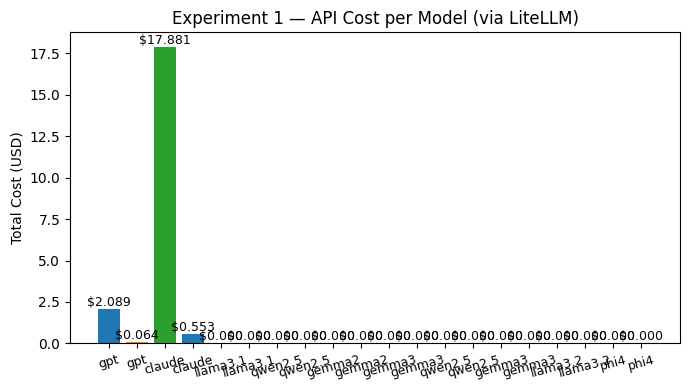

,model,total_usd,mean_per_agent_trial_usd,num_records
0,gpt-4.1-mini,$2.0891,$0.008704,240
1,gpt-4.1-mini (baseline),$0.0644,$0.004294,15
2,claude-sonnet-4-20250514,$17.8811,$0.074505,240
3,claude-sonnet-4-20250514 (baseline),$0.5534,$0.036895,15
4,llama3.1:8b,$0.0000,$0.000000,240
5,llama3.1:8b (baseline),$0.0000,$0.000000,15
6,qwen2.5:7b,$0.0000,$0.000000,240
7,qwen2.5:7b (baseline),$0.0000,$0.000000,15
8,gemma2:9b,$0.0000,$0.000000,240
9,gemma2:9b (baseline),$0.0000,$0.000000,15


In [15]:
# ── 5.  Cost per Model ────────────────────────────────────────────────
df_agg = df_cost.groupby("model", sort=False)["total_usd"].sum().reset_index()
models_c = df_agg["model"].values
costs = df_agg["total_usd"].values
bar_colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(range(len(models_c)), costs, color=bar_colors[:len(models_c)])
ax.set_xticks(range(len(models_c)))
ax.set_xticklabels([m.split(":")[0].split("-")[0] for m in models_c],
                   rotation=15, fontsize=9)
ax.set_ylabel("Total Cost (USD)")
ax.set_title("Experiment 1 — API Cost per Model (via LiteLLM)")
for bar, cost in zip(bars, costs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f"${cost:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

# Cost table
df_cost.style.format({
    "total_usd": "${:.4f}",
    "mean_per_agent_trial_usd": "${:.6f}",
}).set_caption("Cost Summary")

## 6. Key Findings

**All 10 models — FSLSM PRA summary:**

| Model | Params | PRA | DAS | Type |
|---|---|---|---|---|
| claude-sonnet-4-20250514 | ~100B+ | **1.000** | 0.927 | API |
| gemma3:12b | 12B | **1.000** | 0.882 | Local |
| gpt-4.1-mini | ~100B+ | 0.996 | 0.924 | API |
| qwen2.5:7b | 7B | 0.956 | 0.785 | Local |
| gemma2:9b | 9B | 0.948 | 0.837 | Local |
| phi4-mini | 3.8B | 0.915 | 0.722 | Local |
| llama3.2:3b | 3B | 0.902 | 0.708 | Local |
| qwen2.5:3b | 3B | 0.890 | 0.752 | Local |
| llama3.1:8b | 8B | 0.724 | 0.741 | Local |
| gemma3:4b | 4B | 0.718 | 0.718 | Local |

### Key Observations

1. **Commercial LLMs (GPT-4.1-mini, Claude Sonnet) achieve near-perfect PRA** (>=0.996),
   confirming faithful FSLSM encoding via system-prompt persona instructions.

2. **Gemma3:12b matches commercial models** with perfect 1.000 PRA — the strongest local model.

3. **3-4B models are surprisingly capable**: phi4-mini (0.915), llama3.2:3b (0.902), and qwen2.5:3b (0.890)
   all exceed 0.85 PRA, demonstrating that modern small models can maintain multi-dimensional personas.

4. **Model generation matters more than parameter count**: llama3.2:3b (3B, PRA=0.902) dramatically
   outperforms llama3.1:8b (8B, PRA=0.724). Newer training recipes compensate for fewer parameters.

5. **Within-family scaling varies**: Qwen 3B→7B shows modest gain (0.890→0.956), while
   Gemma3 4B→12B shows a massive cliff (0.718→1.000).

6. **gemma3:4b and llama3.1:8b are the weakest** (~0.72 PRA), both failing on similar dimensions
   (sen_int, seq_glo) — abstract persona traits are hardest to maintain.

7. **DAS corroborates PRA** but with more compression: top models cluster at 0.88-0.93 DAS,
   while bottom models cluster at 0.71-0.75 DAS.

8. **Baseline natural styles reveal model family patterns**:
   - API models + Qwen → Reflective-Intuitive (abstract/theoretical tendency)
   - Gemma + Llama3.1 → Active-Sensing-Visual-Sequential (concrete/hands-on tendency)
   - Llama3.2 is an outlier: Active-Intuitive-Visual-Global (mixed)

9. **Cost**: API models incur cost (GPT: ~$2.09, Claude: ~$17.88); all local models run at $0.00 via Ollama.


## 7. Per-Question Alignment Analysis

Alignment rate for each of the 44 ILS questions across all models.
A cell shows the fraction of agent answers that matched the expected answer for the assigned profile pole.
- **1.0** = all agents answered in the direction their profile prescribes
- **0.5** = chance level (no systematic alignment)
- **0.0** = systematic misalignment

Questions are grouped by dimension (act/ref, sen/int, vis/ver, seq/glo).

Saved → results/exp1/figures/per_question_alignment_heatmap.png


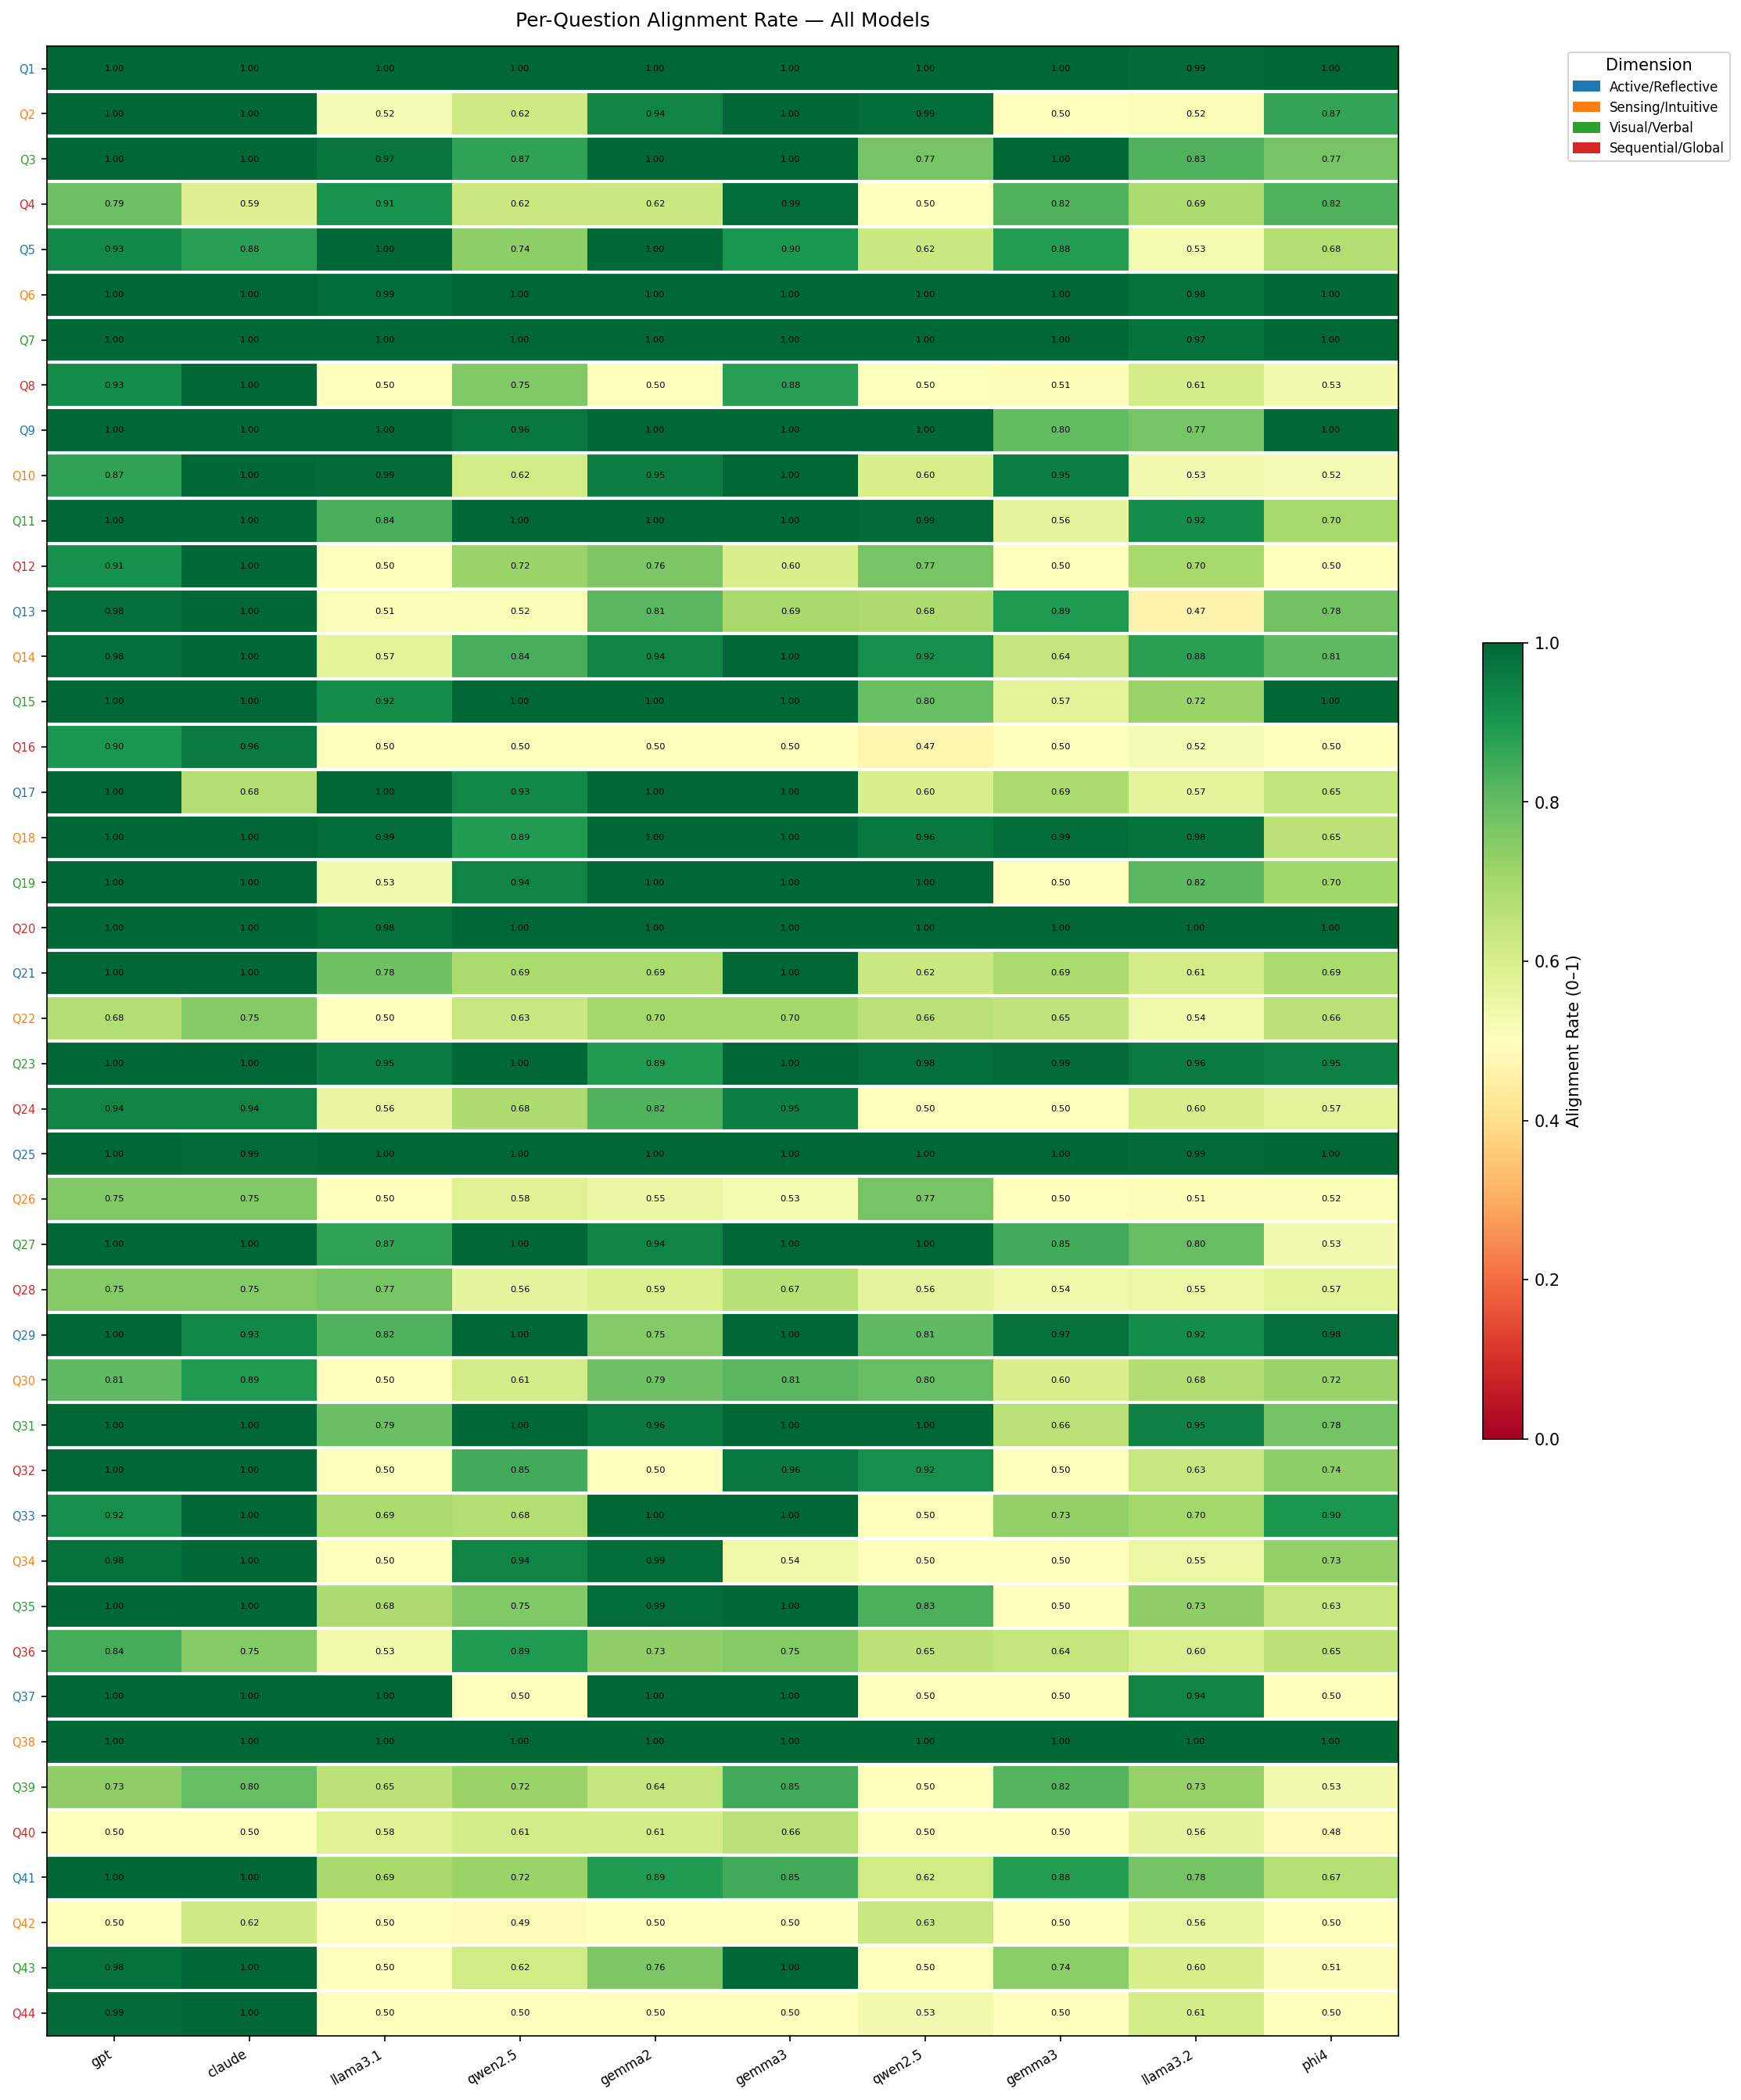

In [16]:
# ── 7.1  Per-Question Alignment Heatmap ─────────────────────────────
from src.evaluation.visualizer import per_question_alignment_heatmap

fig_path = per_question_alignment_heatmap(df_pq)
print(f"Saved → {fig_path}")
from IPython.display import Image
Image(str(fig_path))

In [17]:
# ── 7.2  Per-Dimension Alignment Summary ────────────────────────────
dim_summary = (
    df_pq.groupby(["model", "dimension"])["alignment_rate"]
    .mean()
    .reset_index()
    .pivot(index="dimension", columns="model", values="alignment_rate")
)
dim_summary.style.format("{:.3f}").set_caption("Mean Alignment Rate by Dimension & Model")

model,claude-sonnet-4-20250514,gemma2:9b,gemma3:12b,gemma3:4b,gpt-4.1-mini,llama3.1:8b,llama3.2:3b,phi4-mini,qwen2.5:3b,qwen2.5:7b
dimension,,,,,,,,,,
act_ref,0.953,0.921,0.949,0.822,0.984,0.864,0.751,0.803,0.723,0.794
sen_int,0.910,0.850,0.825,0.712,0.870,0.687,0.700,0.724,0.803,0.747
seq_glo,0.862,0.650,0.769,0.592,0.868,0.622,0.642,0.625,0.628,0.700
vis_ver,0.982,0.925,0.986,0.745,0.974,0.792,0.820,0.736,0.852,0.900


### 7.3 Per-Agent Drill-Down

Inspect any individual agent's 44-question responses across its 3 trials.
- Each cell shows the actual answer letter ("a" or "b")
- **Green** = answer matched the profile's expected pole; **Red** = misaligned
- Y-axis labels are color-coded by dimension (same palette as the aggregate heatmap above)

Use `list_agents(model)` to browse available agent UIDs for a model.

In [18]:
def plot_agent_question_alignment(model: str, agent_uid: str):
    """
    44-question alignment heatmap for a single agent across 3 trials.

    Parameters
    ----------
    model     : model name as stored in results JSON, e.g. "gpt-4.1-mini"
    agent_uid : full agent UID, e.g. "gpt41mini_P01_ActSenVisSeq_I01_beg"
                (use list_agents(model) to browse available UIDs)
    """
    raw_dir = PROJECT_ROOT / "results" / "exp1" / "raw_responses"

    # 1. Find trial files for this agent
    files = sorted(raw_dir.glob(f"{agent_uid}_trial*.json"))
    if not files:
        print(f"No files found for agent_uid={agent_uid!r}")
        return

    # 2. Load questionnaire
    questionnaire = json.loads(
        (PROJECT_ROOT / "data" / "fslsm" / "ils_questionnaire.json").read_text()
    )
    q_lookup = {q["q_num"]: q for q in questionnaire}
    q_nums   = sorted(q_lookup)  # 1..44

    # 3. Resolve assigned profile from FSLSM results JSON
    safe    = model.replace("/", "_").replace(":", "_")
    results = json.loads((METRICS_DIR / f"{safe}_results.json").read_text())
    assigned = next(
        (r["assigned"] for r in results if r["agent_uid"] == agent_uid), None
    )
    if assigned is None:
        print(f"Agent {agent_uid!r} not found in {safe}_results.json")
        return

    # 4. Build 44 × n_trials binary alignment matrix
    trial_labels = []
    trial_cols   = []
    for f in files:
        data    = json.loads(f.read_text())
        answers = {item["q_num"]: item.get("answer") for item in data["raw"]}
        col = []
        for qn in q_nums:
            ans = answers.get(qn)
            if ans not in ("a", "b"):
                col.append(np.nan)
            else:
                q        = q_lookup[qn]
                expected = "a" if q["option_a"]["pole"] == assigned[q["dimension"]] else "b"
                col.append(1.0 if ans == expected else 0.0)
        trial_cols.append(col)
        trial_labels.append(f"Trial {data['trial']}")

    matrix = np.array(trial_cols).T  # shape: (44, n_trials)

    # 5. Render heatmap
    dim_colors = {"act_ref": "#1f77b4", "sen_int": "#ff7f0e",
                  "vis_ver": "#2ca02c", "seq_glo": "#d62728"}
    q_dim = {q["q_num"]: q["dimension"] for q in questionnaire}

    fig, ax = plt.subplots(figsize=(max(4, len(files) * 1.2 + 2), 16))
    im = ax.imshow(matrix, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)

    ax.set_xticks(range(len(trial_labels)))
    ax.set_xticklabels(trial_labels, fontsize=9)
    ax.set_yticks(range(44))
    ax.set_yticklabels([f"Q{qn}" for qn in q_nums], fontsize=7)
    for tick, qn in zip(ax.get_yticklabels(), q_nums):
        tick.set_color(dim_colors[q_dim[qn]])

    # Annotate cells with actual answer letter
    for f_idx, f in enumerate(files):
        data    = json.loads(f.read_text())
        answers = {item["q_num"]: item.get("answer") for item in data["raw"]}
        for i, qn in enumerate(q_nums):
            ans = answers.get(qn, "?")
            ax.text(f_idx, i, ans, ha="center", va="center", fontsize=6.5, color="black")

    # Horizontal dividers between dimension groups
    prev_dim = None
    for i, qn in enumerate(q_nums):
        if q_dim[qn] != prev_dim and prev_dim is not None:
            ax.axhline(i - 0.5, color="white", linewidth=2)
        prev_dim = q_dim[qn]

    profile_str = " | ".join(f"{d}={v:+d}" for d, v in assigned.items())
    ax.set_title(
        f"Per-Question Alignment — {agent_uid}\n"
        f"Model: {model}  |  Profile: {profile_str}",
        fontsize=10, pad=10,
    )
    fig.colorbar(im, ax=ax, shrink=0.3, label="Aligned (1) / Misaligned (0)")

    from matplotlib.patches import Patch
    ax.legend(
        handles=[Patch(color=c, label=d) for d, c in dim_colors.items()],
        loc="upper right", bbox_to_anchor=(1.38, 1.0), fontsize=8, title="Dimension",
    )
    plt.tight_layout()
    plt.show()


def list_agents(model: str):
    """Print available FSLSM agent UIDs for the given model."""
    safe    = model.replace("/", "_").replace(":", "_")
    results = json.loads((METRICS_DIR / f"{safe}_results.json").read_text())
    uids    = sorted({r["agent_uid"] for r in results})
    print(f"{len(uids)} agents for model '{model}':")
    for uid in uids:
        print(f"  {uid}")

| Model | PRA | DAS | Type |
|---|---|---|---|
| claude-sonnet-4-20250514 | **1.000** | 0.927 | API |
| gemma3:12b | **1.000** | 0.882 | Local |
| gpt-4.1-mini | 0.996 | 0.924 | API |
| qwen2.5:7b | 0.956 | 0.785 | Local |
| gemma2:9b | 0.948 | 0.837 | Local |
| llama3.1:8b | 0.724 | 0.741 | Local |

In [19]:
# List available agent UIDs for a model, then plot one

#list_agents("gpt-4.1-mini")
list_agents("llama3.1:8b")

80 agents for model 'llama3.1:8b':
  llama318b_P01_ActSenVisSeq_I01_beg
  llama318b_P01_ActSenVisSeq_I02_int
  llama318b_P01_ActSenVisSeq_I03_adv
  llama318b_P01_ActSenVisSeq_I04_gen
  llama318b_P01_ActSenVisSeq_I05_gen
  llama318b_P02_ActSenVisGlo_I01_beg
  llama318b_P02_ActSenVisGlo_I02_int
  llama318b_P02_ActSenVisGlo_I03_adv
  llama318b_P02_ActSenVisGlo_I04_gen
  llama318b_P02_ActSenVisGlo_I05_gen
  llama318b_P03_ActSenVerSeq_I01_beg
  llama318b_P03_ActSenVerSeq_I02_int
  llama318b_P03_ActSenVerSeq_I03_adv
  llama318b_P03_ActSenVerSeq_I04_gen
  llama318b_P03_ActSenVerSeq_I05_gen
  llama318b_P04_ActSenVerGlo_I01_beg
  llama318b_P04_ActSenVerGlo_I02_int
  llama318b_P04_ActSenVerGlo_I03_adv
  llama318b_P04_ActSenVerGlo_I04_gen
  llama318b_P04_ActSenVerGlo_I05_gen
  llama318b_P05_ActIntVisSeq_I01_beg
  llama318b_P05_ActIntVisSeq_I02_int
  llama318b_P05_ActIntVisSeq_I03_adv
  llama318b_P05_ActIntVisSeq_I04_gen
  llama318b_P05_ActIntVisSeq_I05_gen
  llama318b_P06_ActIntVisGlo_I01_beg
  l

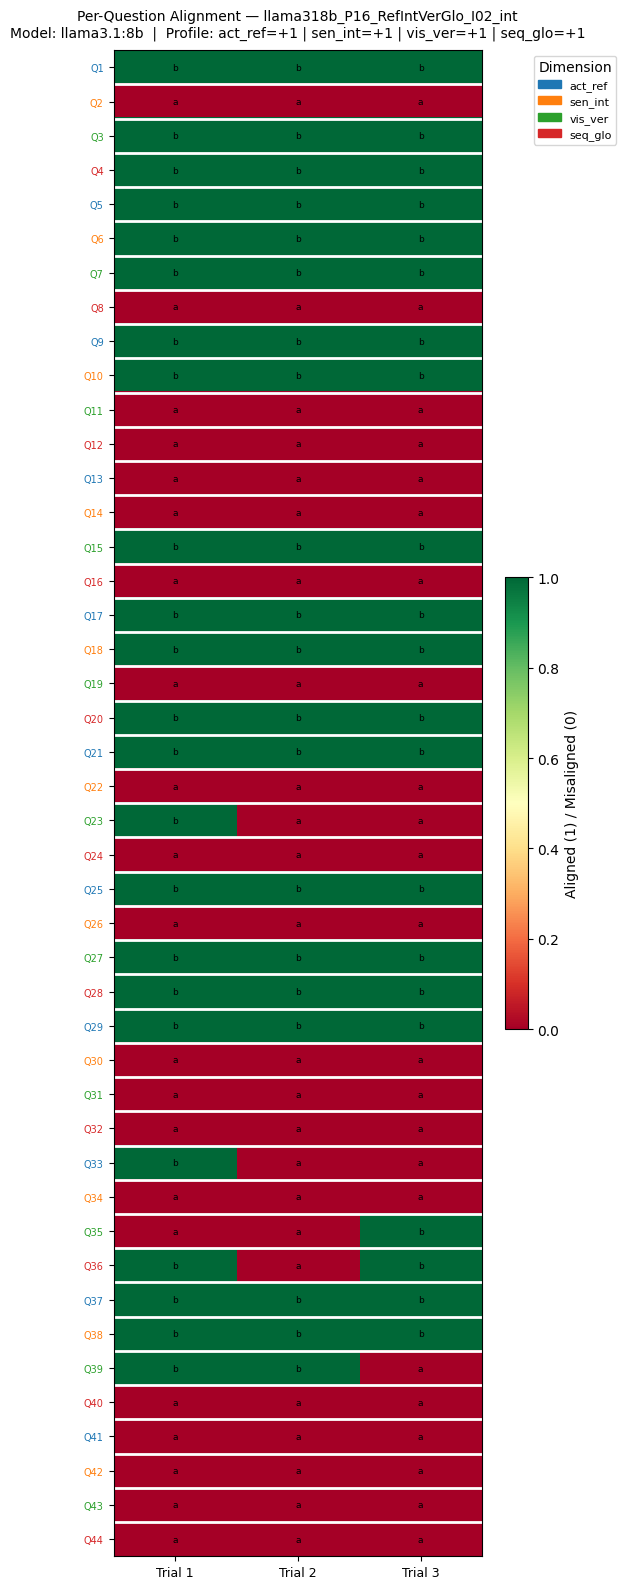

In [20]:
# Plot a specific agent — change model/agent_uid to explore others
plot_agent_question_alignment(
    model="llama3.1:8b",
    agent_uid="llama318b_P16_RefIntVerGlo_I02_int",
)

## 8. Failure Pattern Analysis

Systematic analysis of where and why models fail on the ILS questionnaire.

### 8.1 Per-Dimension PRA Heatmap

Which dimensions are hardest? A 10-model x 4-dimension heatmap reveals that
`seq_glo` (Sequential/Global) and `sen_int` (Sensing/Intuitive) are systematically
the weakest dimensions for small/weak models.

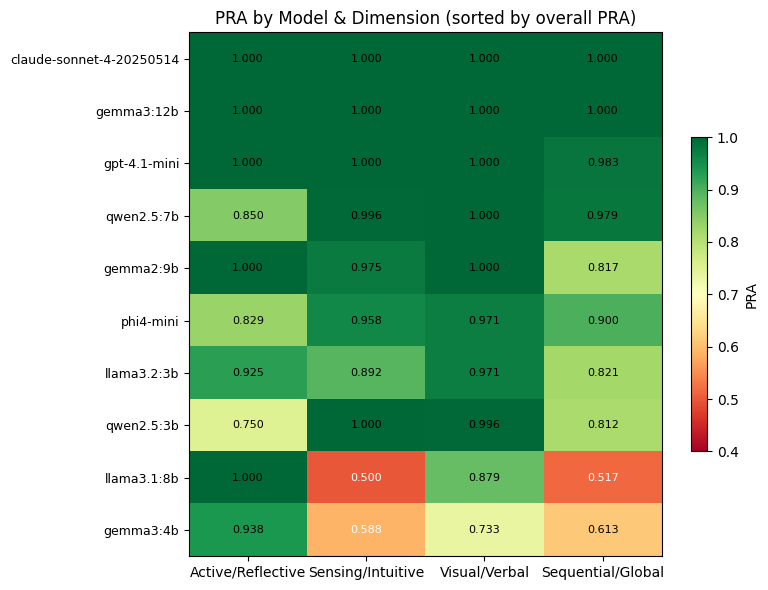

In [21]:
# ── 8.1  Per-Dimension PRA Heatmap ─────────────────────────────────
df_dim = df_pra[
    (df_pra["knowledge_level"] == "ALL") & (df_pra["dimension"] != "overall_4d")
].pivot(index="model", columns="dimension", values="pra")

# Reorder columns and rows for readability
df_dim = df_dim[FSLSM_DIMENSIONS]
# Sort by overall PRA (best → worst)
overall = df_pra[
    (df_pra["knowledge_level"] == "ALL") & (df_pra["dimension"] == "overall_4d")
].set_index("model")["pra"]
df_dim = df_dim.loc[overall.sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(df_dim.values, cmap="RdYlGn", aspect="auto", vmin=0.4, vmax=1.0)
ax.set_xticks(range(len(FSLSM_DIMENSIONS)))
ax.set_xticklabels(DIM_AXIS_LABELS, fontsize=10)
ax.set_yticks(range(len(df_dim)))
ax.set_yticklabels(df_dim.index, fontsize=9)
for i in range(len(df_dim)):
    for j in range(len(FSLSM_DIMENSIONS)):
        val = df_dim.values[i, j]
        ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=8,
                color="white" if val < 0.6 else "black")
ax.set_title("PRA by Model & Dimension (sorted by overall PRA)", fontsize=12)
fig.colorbar(im, ax=ax, shrink=0.6, label="PRA")
plt.tight_layout()
plt.show()

### 8.2 Hardest ILS Questions

Bottom 15 questions ranked by mean alignment rate across all 10 models.
Questions at ~0.50 indicate random guessing — models have zero understanding
of the distinction being tested.

In [22]:
# ── 8.2  Hardest ILS Questions ──────────────────────────────────────
# Mean alignment per question across all models
q_pivot = df_pq.pivot(index=["q_num", "dimension"], columns="model",
                      values="alignment_rate").reset_index()
q_pivot["mean_alignment"] = q_pivot[MODELS].mean(axis=1)
q_pivot = q_pivot.sort_values("mean_alignment")

# Show bottom 15
bottom15 = q_pivot.head(15).copy()
display_cols = ["q_num", "dimension", "mean_alignment"] + MODELS
bottom15[display_cols].style.format(
    {c: "{:.3f}" for c in ["mean_alignment"] + MODELS}
).background_gradient(
    cmap="RdYlGn", subset=MODELS, vmin=0.4, vmax=1.0
).set_caption("15 Hardest ILS Questions (lowest mean alignment across all models)")

model,q_num,dimension,mean_alignment,gpt-4.1-mini,claude-sonnet-4-20250514,llama3.1:8b,qwen2.5:7b,gemma2:9b,gemma3:12b,qwen2.5:3b,gemma3:4b,llama3.2:3b,phi4-mini
41,42,sen_int,0.530,0.500,0.621,0.500,0.492,0.500,0.500,0.629,0.500,0.561,0.500
39,40,seq_glo,0.551,0.500,0.500,0.583,0.613,0.608,0.662,0.500,0.500,0.564,0.483
15,16,seq_glo,0.585,0.900,0.958,0.500,0.504,0.500,0.500,0.471,0.500,0.521,0.500
25,26,sen_int,0.597,0.754,0.754,0.500,0.583,0.554,0.525,0.771,0.500,0.508,0.517
43,44,seq_glo,0.613,0.992,1.000,0.500,0.500,0.500,0.500,0.529,0.500,0.606,0.500
27,28,seq_glo,0.631,0.750,0.750,0.771,0.562,0.592,0.667,0.562,0.537,0.549,0.571
21,22,sen_int,0.647,0.675,0.750,0.500,0.633,0.700,0.700,0.662,0.650,0.539,0.662
7,8,seq_glo,0.671,0.925,1.000,0.500,0.754,0.500,0.879,0.504,0.508,0.609,0.529
11,12,seq_glo,0.696,0.912,1.000,0.500,0.717,0.762,0.600,0.771,0.500,0.699,0.500
38,39,vis_ver,0.697,0.733,0.800,0.654,0.717,0.642,0.846,0.500,0.821,0.726,0.529


### 8.3 Baseline Bias vs Dimension PRA

Hypothesis: models fail more on dimensions where their natural baseline opposes
the assigned profile. The scatter plot shows each model's baseline mean score
(x-axis) vs its PRA on that dimension (y-axis) — 40 points (10 models x 4 dims).

A strong baseline bias (far from 0) might indicate the model is "stuck" in its
natural style and cannot adopt the opposite pole when instructed.

Baseline mean score (top) vs PRA (bottom) per dimension:


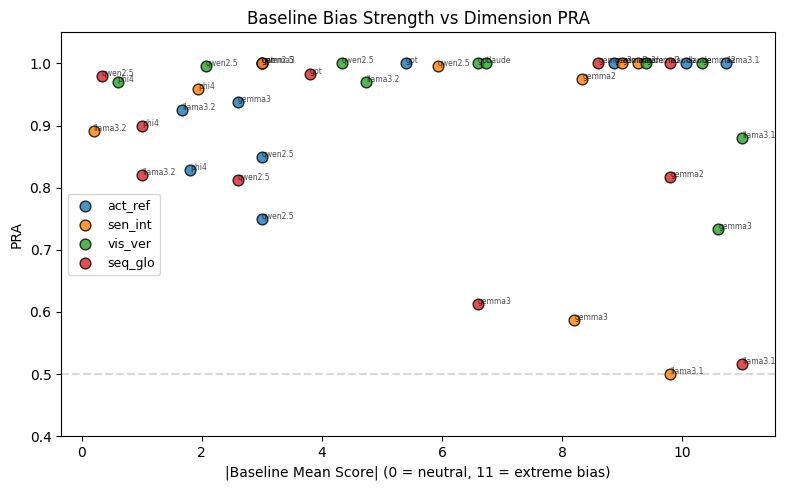

In [23]:
# ── 8.3  Baseline Bias vs Dimension PRA ─────────────────────────────
rows = []
for _, brow in df_baseline_style.iterrows():
    model = brow["model"]
    for dim in FSLSM_DIMENSIONS:
        bias = brow[f"{dim}_mean_score"]
        pra_val = df_pra[
            (df_pra["model"] == model)
            & (df_pra["dimension"] == dim)
            & (df_pra["knowledge_level"] == "ALL")
        ]["pra"].values
        if len(pra_val):
            rows.append({"model": model, "dimension": dim,
                         "baseline_score": bias, "abs_baseline": abs(bias),
                         "pra": pra_val[0]})

df_bias = pd.DataFrame(rows)

# Table
bias_pivot = df_bias.pivot(index="model", columns="dimension",
                           values=["baseline_score", "pra"])
print("Baseline mean score (top) vs PRA (bottom) per dimension:")
display(bias_pivot.style.format("{:.3f}"))

# Scatter: |baseline_score| vs PRA
dim_colors = {"act_ref": "#1f77b4", "sen_int": "#ff7f0e",
              "vis_ver": "#2ca02c", "seq_glo": "#d62728"}
fig, ax = plt.subplots(figsize=(8, 5))
for dim in FSLSM_DIMENSIONS:
    subset = df_bias[df_bias["dimension"] == dim]
    ax.scatter(subset["abs_baseline"], subset["pra"],
               c=dim_colors[dim], label=dim, s=60, alpha=0.8, edgecolors="black")
    for _, r in subset.iterrows():
        ax.annotate(r["model"].split(":")[0].split("-")[0],
                    (r["abs_baseline"], r["pra"]),
                    fontsize=5.5, alpha=0.7)

ax.set_xlabel("|Baseline Mean Score| (0 = neutral, 11 = extreme bias)", fontsize=10)
ax.set_ylabel("PRA", fontsize=10)
ax.set_ylim(0.4, 1.05)
ax.set_title("Baseline Bias Strength vs Dimension PRA", fontsize=12)
ax.legend(fontsize=9)
ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()